In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
sys.path.append("../")

from src.utils import *

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [3]:
agricultura = pd.read_csv('../data/raw/Datos_agricultura_25.csv')
ipi_esp = pd.read_excel('../data/raw/IPI_Esp.xlsx')
drones = pd.read_excel('../data/raw/Datos_drones_25.xlsx')

In [4]:
import warnings
warnings.filterwarnings('ignore')

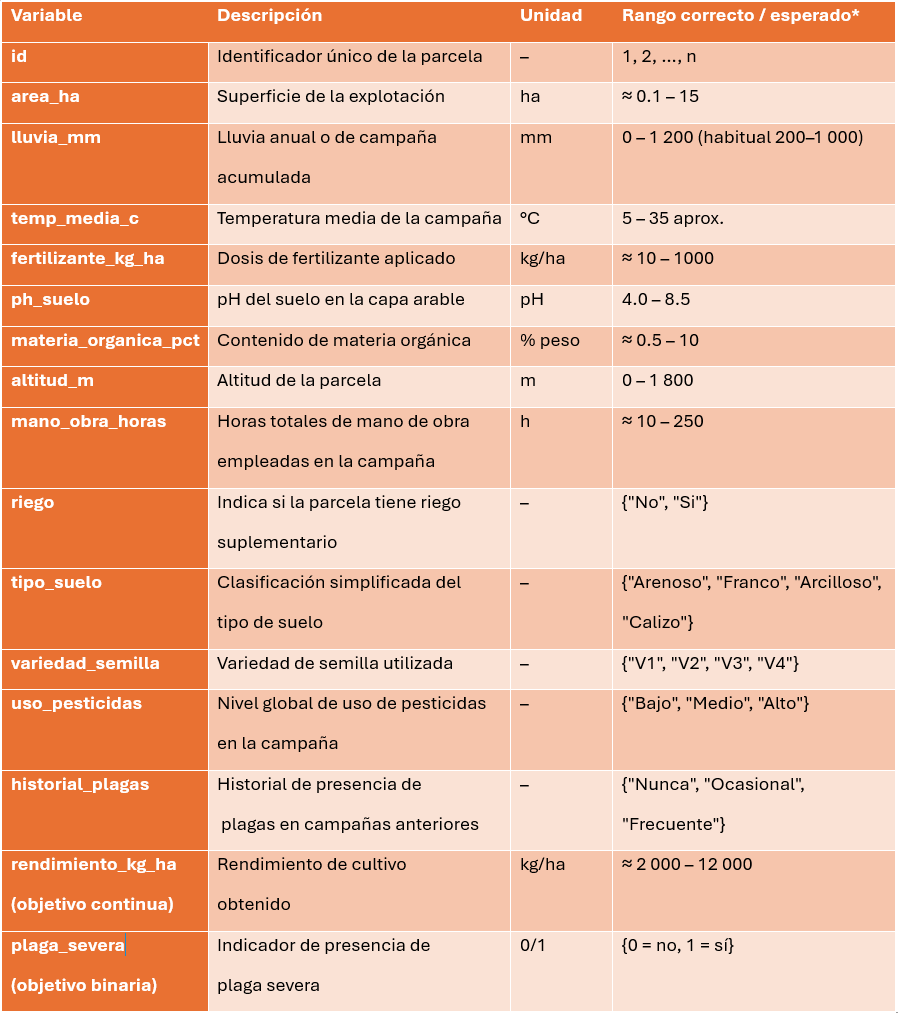

In [5]:
from IPython.display import Image, display

display(Image(filename="../data/raw/Tabla_Variables_Agri.png", width=600))


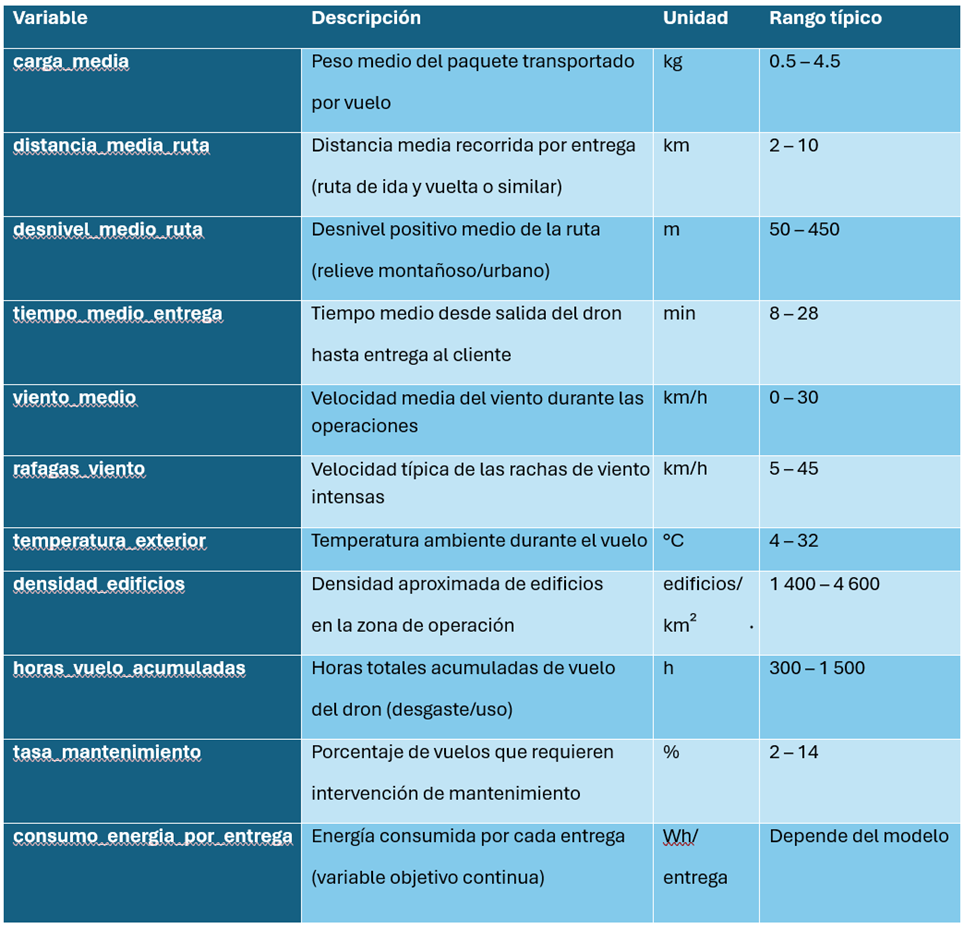

In [6]:
from IPython.display import Image, display
display(Image(filename="../data/raw/Tabla_drones.png", width=600))



In [7]:
agricultura = pd.read_csv('../data/raw/Datos_agricultura_25.csv')
agricultura.head()

,Unnamed: 0,id,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas,rendimiento_kg_ha,plaga_severa
0,0,1,1.639907,418.912109,12.947372,80.112469,6.378618,0.961564,564.350321,117.657884,Si,Franco,V1,Alto,Nunca,6320.282655,0
1,1,2,3.181230,829.883681,13.273468,120.907585,6.510040,5.700165,848.351457,118.783270,Si,Franco,V2,Medio,Nunca,8011.839833,1
2,2,3,2.335113,NaN,15.318376,116.182533,6.338459,1.862246,471.860055,158.016439,No,Franco,V1,NaN,Frecuente,6380.726608,1
3,3,4,3.380414,596.452294,21.758124,259.092031,7.016593,7.405093,792.009663,99.675733,No,Arcilloso,V2,Medio,Ocasional,6969.167513,1
4,4,5,2.119452,468.527190,17.286543,116.321076,5.538014,0.371970,359.044071,95.332274,Si,Arenoso,V1,Alto,Frecuente,6416.729743,1


In [8]:
#Info del dataset
agricultura.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            3600 non-null   int64  
 1   id                    3600 non-null   int64  
 2   area_ha               3600 non-null   float64
 3   lluvia_mm             3492 non-null   float64
 4   temp_media_c          3600 non-null   float64
 5   fertilizante_kg_ha    3600 non-null   float64
 6   ph_suelo              3564 non-null   float64
 7   materia_organica_pct  3528 non-null   float64
 8   altitud_m             3600 non-null   float64
 9   mano_obra_horas       3600 non-null   float64
 10  riego                 3600 non-null   object 
 11  tipo_suelo            3600 non-null   object 
 12  variedad_semilla      3600 non-null   object 
 13  uso_pesticidas        2880 non-null   object 
 14  historial_plagas      3600 non-null   object 
 15  rendimiento_kg_ha    

In [9]:
ipi_esp = pd.read_excel('../data/raw/IPI_Esp.xlsx')
ipi_esp.head()

,Date,IPI Nacional
0,1975M01,70.658
1,1975M02,72.180
2,1975M03,75.732
3,1975M04,74.844
4,1975M05,74.210


In [10]:
# Lectura datos drones
drones=pd.read_excel('../data/raw/Datos_drones_25.xlsx')
drones.head()

,Unnamed: 0,carga_media,distancia_media_ruta,desnivel_medio_ruta,tiempo_medio_entrega,viento_medio,rafagas_viento,temperatura_exterior,densidad_edificios,horas_vuelo_acumuladas,tasa_mantenimiento,consumo_energia_por_entrega
0,0,3.516321,4.012980,364.339877,13.204373,9.705709,31.813419,17.088730,1567.771831,927.729288,1.765021,79.928719
1,1,1.291121,3.243403,324.781439,23.058810,2.433859,42.195099,11.255649,3950.373410,935.288648,8.961053,61.173511
2,2,0.701340,4.445645,320.917020,25.192340,12.357138,28.441942,2.757923,3594.852928,678.476208,6.398269,67.613639
3,3,1.768346,7.551582,192.266707,23.525792,14.953837,25.177178,20.490093,3872.323027,846.657310,8.684453,74.351774
4,4,3.721639,5.684206,242.498209,15.133995,13.975283,27.088913,24.486237,1811.492315,162.696500,13.019751,75.758522


In [11]:
agricultura.nunique()

Unnamed: 0              3600
id                      3600
area_ha                 3600
lluvia_mm               3483
temp_media_c            3591
fertilizante_kg_ha      3600
ph_suelo                3544
materia_organica_pct    3528
altitud_m               3451
mano_obra_horas         3593
riego                      2
tipo_suelo                 5
variedad_semilla           4
uso_pesticidas             3
historial_plagas           3
rendimiento_kg_ha       3600
plaga_severa               2
dtype: int64

In [12]:
rangos = {
    'lluvia_mm': (0, 1300),
    'temp_media_c': (5, 35),
    'fertilizante_kg_ha': (10, 1000),
    'ph_suelo': (4, 8.5),
    'materia_organica_pct': (0.5, 10)
}

for var, (min_val, max_val) in rangos.items():
    n_fuera = (~agricultura[var].between(min_val, max_val)).sum()
    print(f"{var}: {n_fuera} valores fuera de rango")

lluvia_mm: 119 valores fuera de rango
temp_media_c: 12 valores fuera de rango
fertilizante_kg_ha: 6 valores fuera de rango
ph_suelo: 54 valores fuera de rango
materia_organica_pct: 181 valores fuera de rango


In [13]:
to_factor = list(agricultura.loc[:,agricultura.nunique() <= 10]);
print(to_factor)


agricultura[to_factor] = agricultura[to_factor].astype('category')

['riego', 'tipo_suelo', 'variedad_semilla', 'uso_pesticidas', 'historial_plagas', 'plaga_severa']


In [14]:
agricultura.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Unnamed: 0            3600 non-null   int64   
 1   id                    3600 non-null   int64   
 2   area_ha               3600 non-null   float64 
 3   lluvia_mm             3492 non-null   float64 
 4   temp_media_c          3600 non-null   float64 
 5   fertilizante_kg_ha    3600 non-null   float64 
 6   ph_suelo              3564 non-null   float64 
 7   materia_organica_pct  3528 non-null   float64 
 8   altitud_m             3600 non-null   float64 
 9   mano_obra_horas       3600 non-null   float64 
 10  riego                 3600 non-null   category
 11  tipo_suelo            3600 non-null   category
 12  variedad_semilla      3600 non-null   category
 13  uso_pesticidas        2880 non-null   category
 14  historial_plagas      3600 non-null   category
 15  rend

In [15]:
agricultura.describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,3600.0,1799.5,1039.4,0.0,899.8,1799.5,2699.2,3599.0
id,3600.0,1800.5,1039.4,1.0,900.8,1800.5,2700.2,3600.0
area_ha,3600.0,3.6,2.1,0.2,2.1,3.2,4.7,14.9
lluvia_mm,3492.0,616.8,191.5,-50.0,493.0,616.6,749.3,1301.3
temp_media_c,3600.0,18.2,4.6,4.1,15.4,18.1,20.8,60.0
fertilizante_kg_ha,3600.0,150.9,122.4,10.6,81.3,122.5,184.2,3230.9
ph_suelo,3564.0,6.5,0.9,-1.0,6.0,6.5,7.0,14.0
materia_organica_pct,3528.0,3.0,1.9,0.1,1.6,2.6,4.0,18.9
altitud_m,3600.0,453.8,251.2,0.0,269.1,449.9,627.4,1329.7
mano_obra_horas,3600.0,120.1,39.4,10.0,93.4,120.9,147.5,242.1


Valores fuera de los rangos:

**lluvia_mm** presenta valores negativos (mínimo = −50) y valores superiores al rango esperado (máximo = 1301.3).

**temp_media_c** muestra un valor máximo de 60 °C, superior al rango habitual.

**fertilizante_kg_ha** presenta valores extremadamente altos (máximo = 3230.9).

**ph_suelo** presenta valores fuera de rango (mínimo = −1 y máximo = 14).

**materia_organica_pct** presenta valores máximos demasiado elevados (18.9).

Valores faltantes:

**lluvia_mm**, **ph_suelo** y **materia_organica_pct**

In [16]:
agricultura.describe(exclude=np.number).T

,count,unique,top,freq
riego,3600,2,No,1977
tipo_suelo,3600,5,Franco,1307
variedad_semilla,3600,4,V2,1266
uso_pesticidas,2880,3,Bajo,1391
historial_plagas,3600,3,Nunca,2156
plaga_severa,3600,2,0,2110


Valores faltantes en **uso_pesticidas** y en **tipo_suelo** hay 5 variables aunque en la tabla de variables aparecen 4 tipos.

In [17]:
def plot(x):
    plt.figure(figsize=(6,4))
    sns.histplot(x, kde=True)
    plt.title(x.name)
    plt.show()

In [18]:
from src.utils import *

Cont


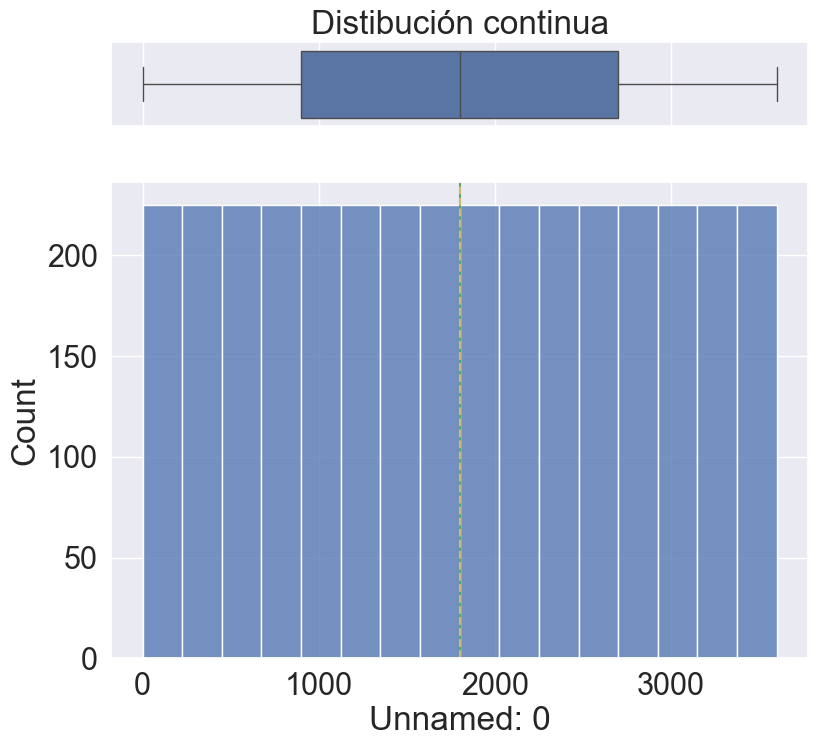

Cont


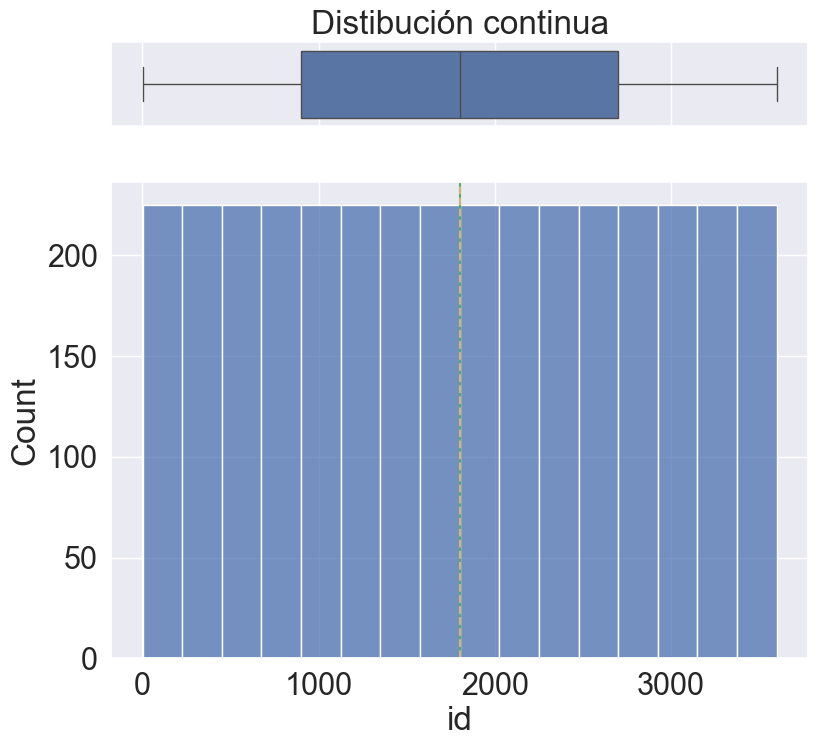

Cont


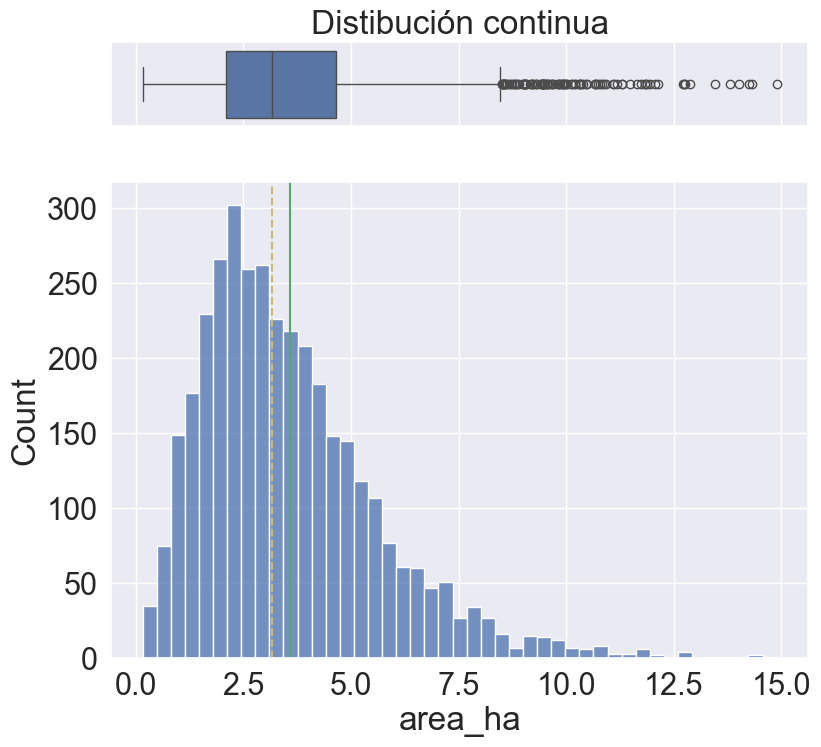

Cont


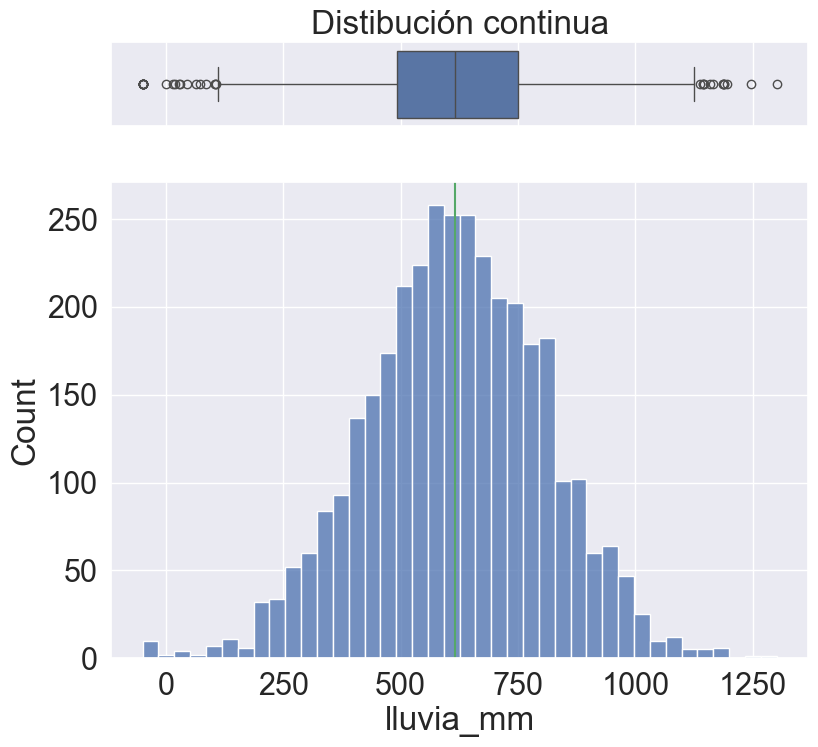

Cont


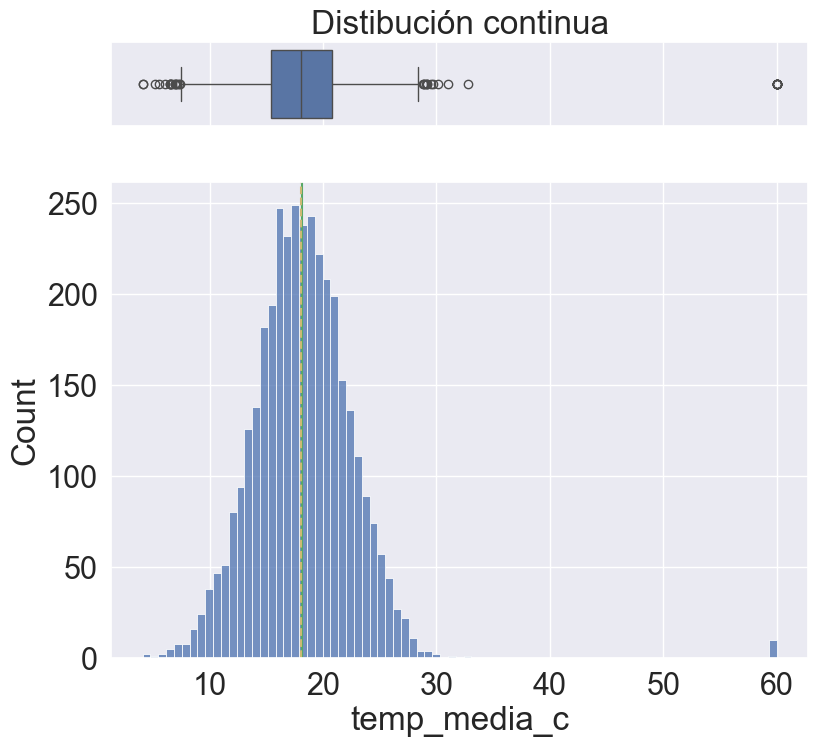

Cont


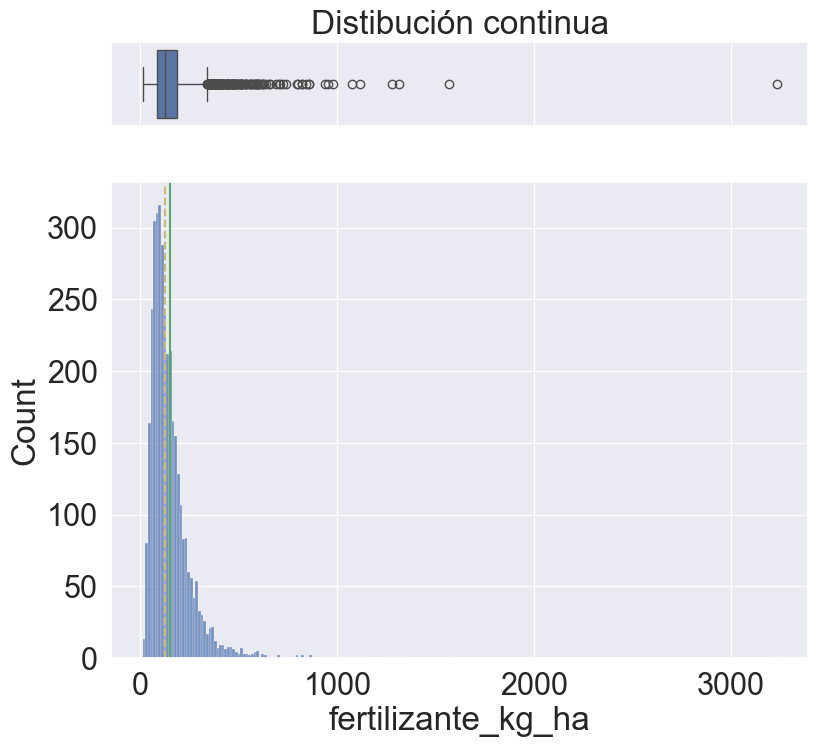

Cont


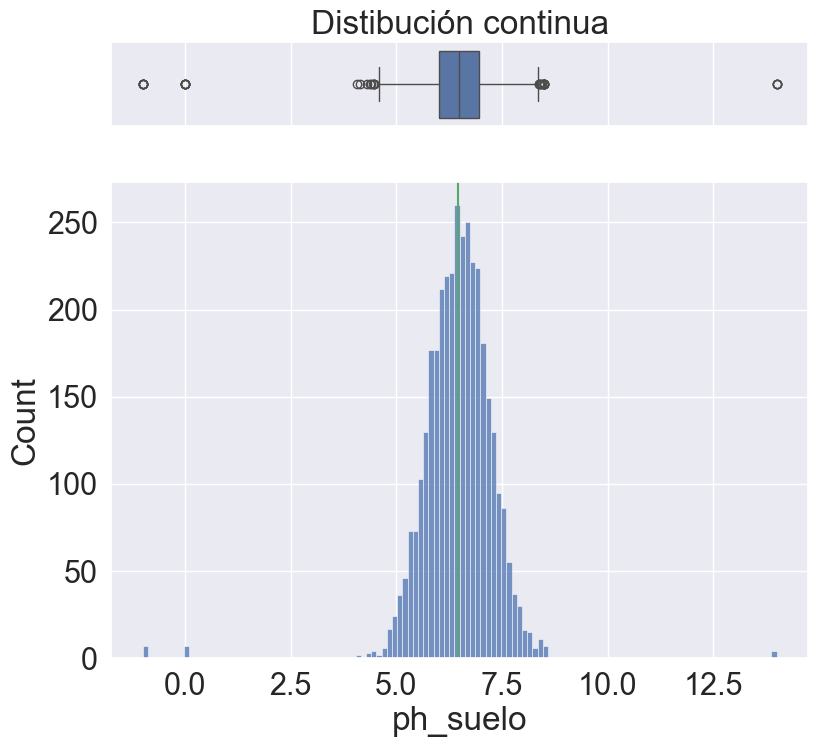

Cont


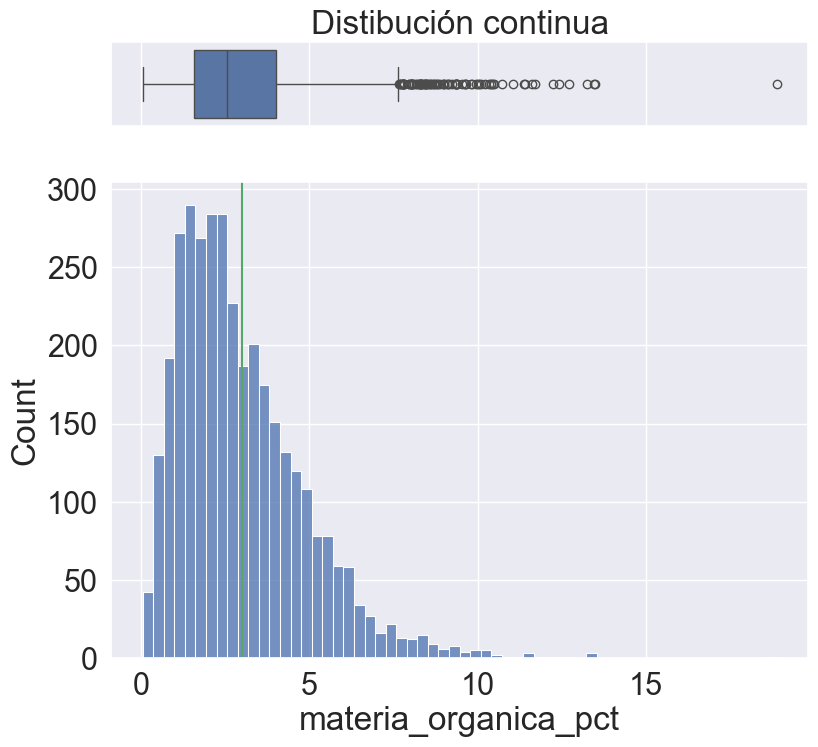

Cont


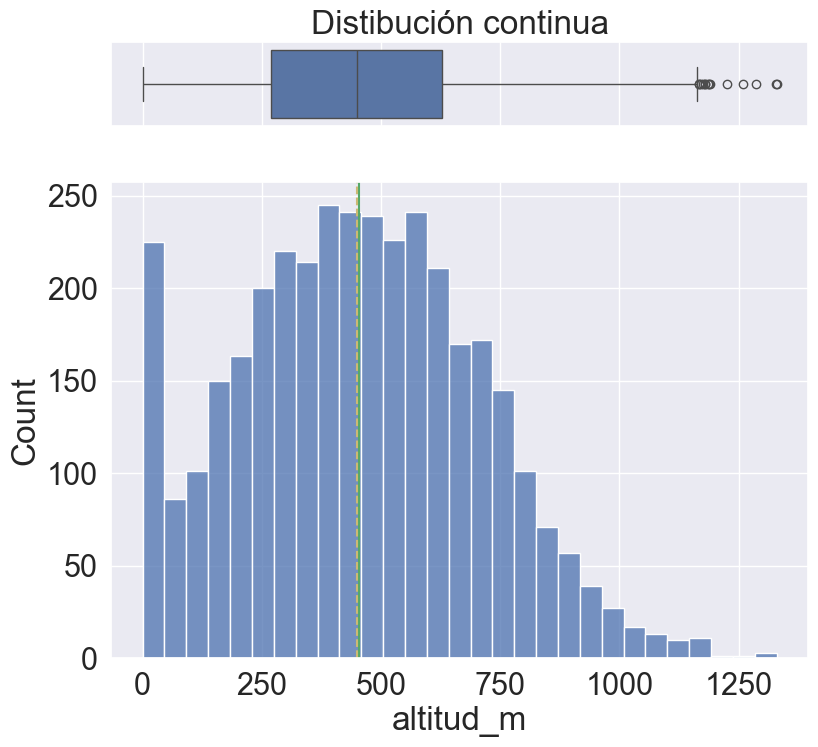

Cont


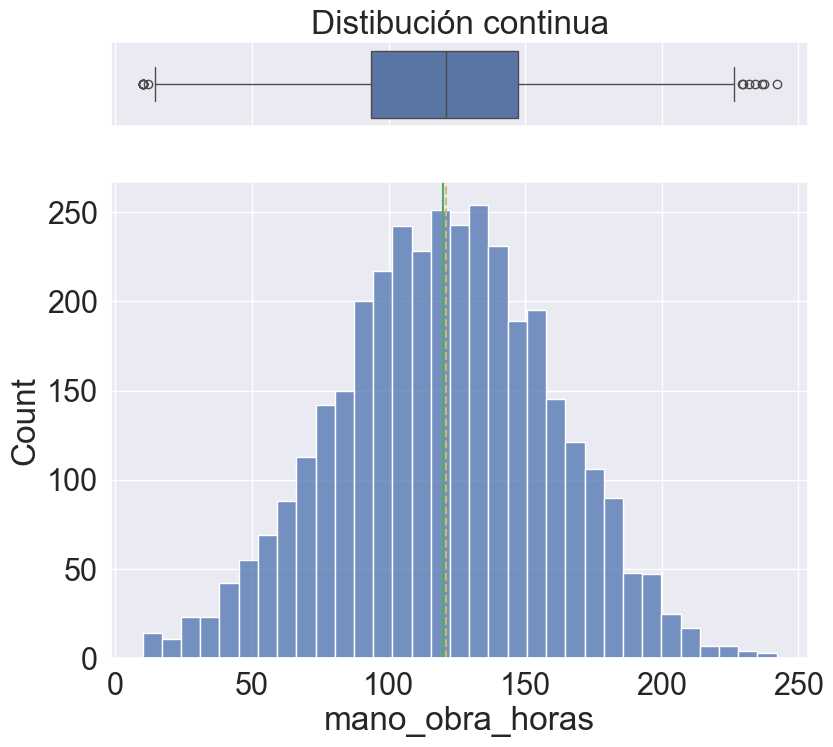

Cat


Cat


Cat


Cat


Cat


Cont


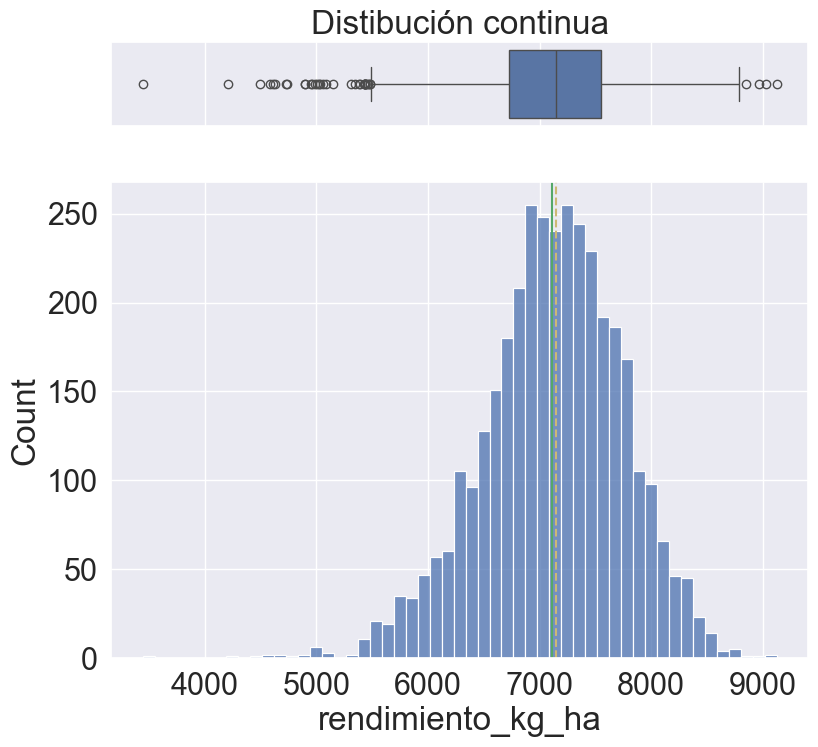

Cat


Unnamed: 0              None
id                      None
area_ha                 None
lluvia_mm               None
temp_media_c            None
fertilizante_kg_ha      None
ph_suelo                None
materia_organica_pct    None
altitud_m               None
mano_obra_horas         None
riego                   None
tipo_suelo              None
variedad_semilla        None
uso_pesticidas          None
historial_plagas        None
rendimiento_kg_ha       None
plaga_severa            None
dtype: object

In [19]:
agricultura.apply(plot)

# **CORRECCIÓN DE ERRORES DETECTADOS**

1. Se encuentran 5 categorías de tipo de suelo en vez de 4

In [20]:
agricultura.tipo_suelo.value_counts() #Vemos que hay dos Franco

tipo_suelo
Franco       1307
Arcilloso     901
Arenoso       886
Calizo        367
 Franco       139
Name: count, dtype: int64

In [21]:
agricultura['tipo_suelo'].unique() #Vemos que era debido a un espacio

['Franco', 'Arcilloso', 'Arenoso', 'Calizo', ' Franco']
Categories (5, object): [' Franco', 'Arcilloso', 'Arenoso', 'Calizo', 'Franco']

In [22]:
#Quitamos el espacio y creamos las categorías correctamente
agricultura['tipo_suelo'] = agricultura['tipo_suelo'].astype(str).str.strip()
agricultura['tipo_suelo'] = agricultura['tipo_suelo'].astype('category')

In [23]:
#Comprobamos que quedan 4 categorías
agricultura['tipo_suelo'].value_counts()

tipo_suelo
Franco       1446
Arcilloso     901
Arenoso       886
Calizo        367
Name: count, dtype: int64

2. **lluvia_mm** no puede tener valores negativos

In [24]:
#Ver cuántos son inválidos y vemos que solo hay valores de -50.0
agricultura.loc[agricultura['lluvia_mm'] < 0, 'lluvia_mm'].head()

489    -50.0
537    -50.0
804    -50.0
1762   -50.0
2158   -50.0
Name: lluvia_mm, dtype: float64

In [25]:
#Quitamos los -50.0 y los pasamos a NA
agricultura.lluvia_mm.replace(-50, np.nan, inplace=True)

#Comprobamos que se ha ejecutado correctamente
agricultura.lluvia_mm.describe()

count    3482.000000
mean      618.720015
std       188.427073
min         0.000000
25%       494.257405
50%       617.009300
75%       749.707322
max      1301.291583
Name: lluvia_mm, dtype: float64

Cont


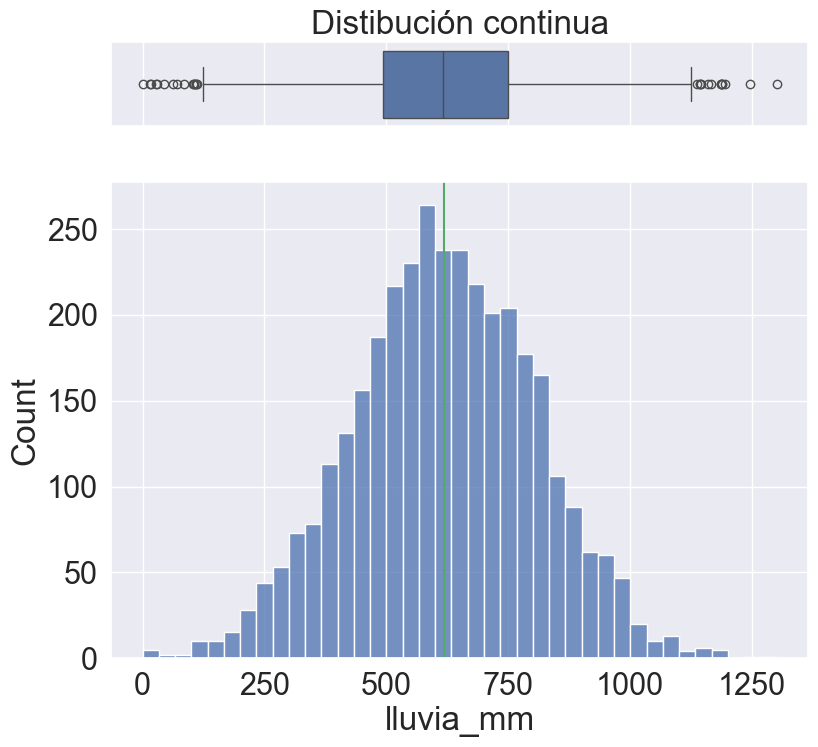

In [26]:
#Comprobamos en histograma
plot(agricultura.lluvia_mm)

3. En **ph_suelo** existen valores extremos (min = -1
max = 14) fuera de los normales (4 – 8.5)

In [27]:
#Pasamos a nan
agricultura.loc[~agricultura['ph_suelo'].between(4, 8.5), 'ph_suelo'] = np.nan

#Comprobamos
agricultura['ph_suelo'].describe()

count    3546.000000
mean        6.486866
std         0.690045
min         4.066092
25%         6.017947
50%         6.494370
75%         6.954414
max         8.500000
Name: ph_suelo, dtype: float64

Cont


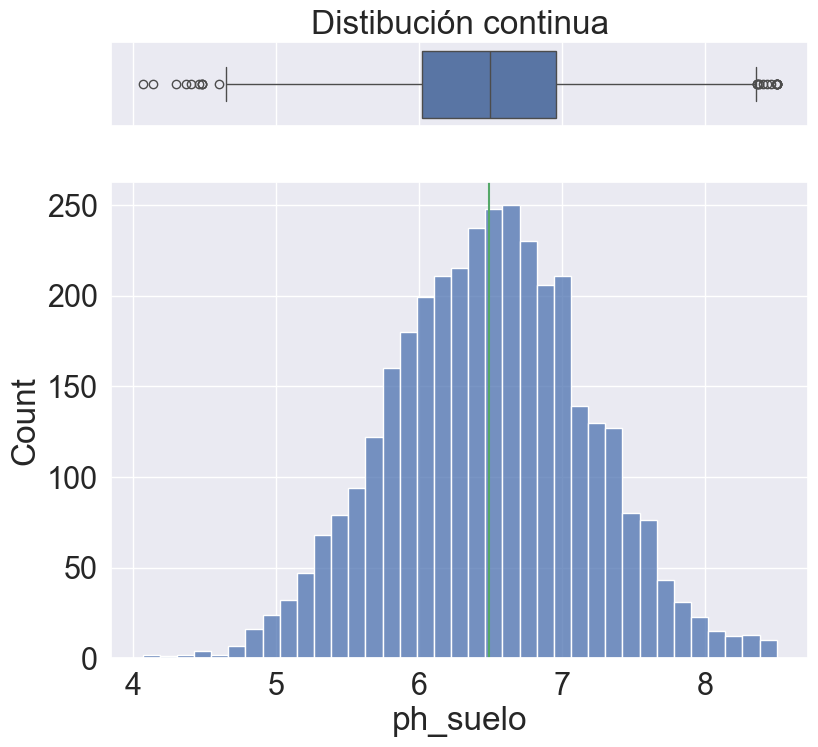

In [28]:
#Comprobamos en histograma
plot(agricultura.ph_suelo)

4. **temp_media_c** tiene valores muy por encima de 35 grados.

In [29]:
#Como en la tabla de variables indica que la temperatura se encuentra entre 5-35 aprox, se mantienen los valores cercanos al límite inferior y eliminamos los que se encuentran muy lejos de 35
#Vemos cuantos valores hay por encima de 35 grados y comprobamos que todos son 60 grados

agricultura.loc[agricultura['temp_media_c'] > 35, 'temp_media_c']

138     60.0
160     60.0
314     60.0
408     60.0
602     60.0
730     60.0
1036    60.0
1117    60.0
1552    60.0
3216    60.0
Name: temp_media_c, dtype: float64

Cont


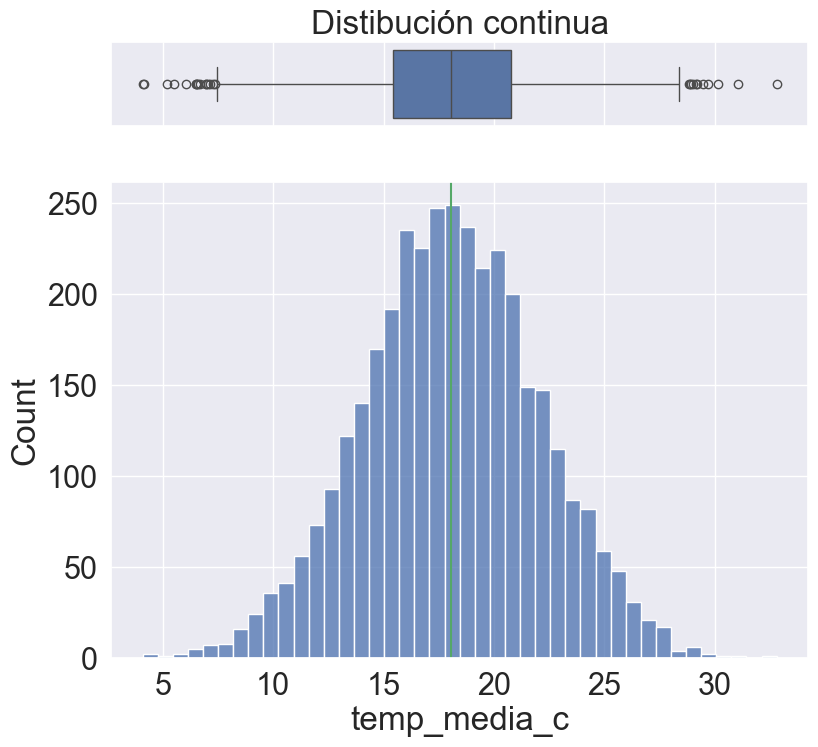

In [30]:
#Los corregimos
agricultura.loc[agricultura['temp_media_c'] > 35, 'temp_media_c'] = np.nan

#Comprobamos en el histograma
plot(agricultura.temp_media_c)

5. **fertilizante_kg_ha** debería tener valores de ≈10-1000 y vemos máximos: de 3230.9


In [31]:
agricultura.fertilizante_kg_ha.describe()

count    3600.000000
mean      150.944151
std       122.427301
min        10.631405
25%        81.330456
50%       122.537424
75%       184.241773
max      3230.906894
Name: fertilizante_kg_ha, dtype: float64

In [32]:
#Vemos cuántos valores hay por encima de 1000
agricultura.loc[agricultura['fertilizante_kg_ha'] > 1000, 'fertilizante_kg_ha']

637     1313.030311
2191    1568.088721
2353    1114.189973
2463    3230.906894
3109    1279.118772
3412    1074.349149
Name: fertilizante_kg_ha, dtype: float64

In [33]:
#Corregimos el valor extremo y comprobamos, aunque consideramos dudoso el valor de 1568
agricultura.loc[agricultura['fertilizante_kg_ha'] > 2000, 'fertilizante_kg_ha'] = np.nan
agricultura.fertilizante_kg_ha.describe()

count    3599.000000
mean      150.088368
std       111.154691
min        10.631405
25%        81.327006
50%       122.522048
75%       184.154920
max      1568.088721
Name: fertilizante_kg_ha, dtype: float64

Consideramos **1568** posible y decidimos mantenerlo para su posterior análisis en el estudio de outliers.

6. **materia_organica_pct** tiene un rango esperado de ≈0.5-10 y hay valores máximos de 18

In [34]:
agricultura.materia_organica_pct.describe()

count    3528.000000
mean        2.991493
std         1.911530
min         0.052297
25%         1.582046
50%         2.564343
75%         4.001123
max        18.875801
Name: materia_organica_pct, dtype: float64

In [35]:
#Vemos cuales son esos valores
agricultura.loc[agricultura['materia_organica_pct'] > 10, 'materia_organica_pct']

193     12.239952
540     10.476506
550     13.445776
633     10.106510
761     10.457838
1410    10.042762
1451    18.875801
1491    13.252220
1524    13.485817
1545    11.600565
1663    10.002270
1897    10.402007
2266    11.708602
2958    12.402037
3068    12.708810
3115    11.394449
3239    10.724373
3241    11.362203
3310    10.218398
3324    11.038583
3444    10.326677
3471    10.403361
Name: materia_organica_pct, dtype: float64

In [36]:
#Consideramos que son posibles valores algo superiores a 10, por lo que se mantienen los valores hasta 15 y solo se califica como missing el valor extremo de 18.88
agricultura.loc[agricultura['materia_organica_pct'] > 15, 'materia_organica_pct'] = np.nan

agricultura.materia_organica_pct.describe()

count    3527.000000
mean        2.986989
std         1.892988
min         0.052297
25%         1.581739
50%         2.563791
75%         4.000521
max        13.485817
Name: materia_organica_pct, dtype: float64

Cont


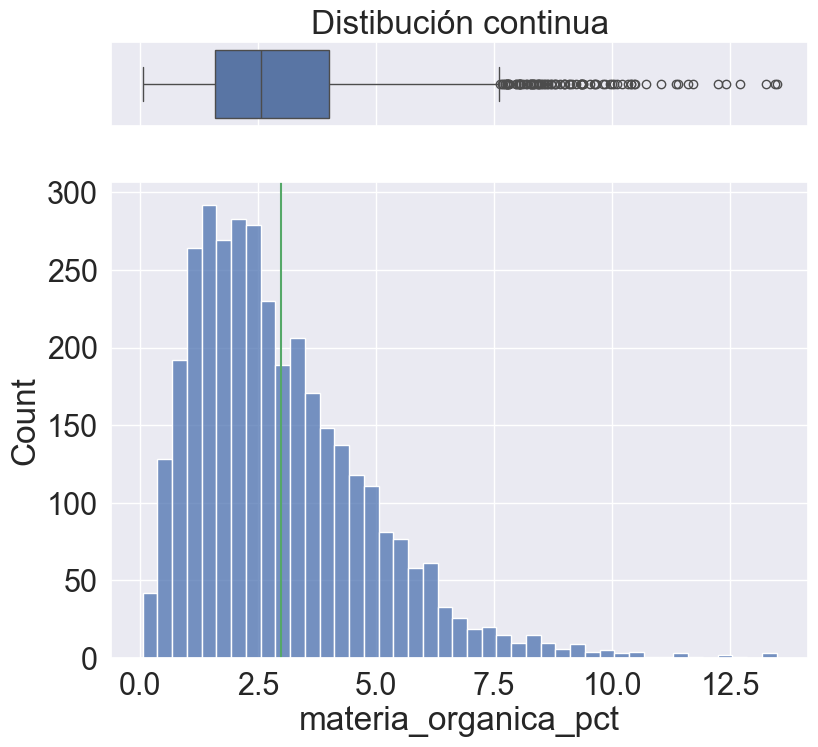

In [37]:
#Comprobamos en el histograma
plot(agricultura.materia_organica_pct)

In [38]:
# Distribuciones de las variables corregidas
agricultura.describe().round(1).T


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,3600.0,1799.5,1039.4,0.0,899.8,1799.5,2699.2,3599.0
id,3600.0,1800.5,1039.4,1.0,900.8,1800.5,2700.2,3600.0
area_ha,3600.0,3.6,2.1,0.2,2.1,3.2,4.7,14.9
lluvia_mm,3482.0,618.7,188.4,0.0,494.3,617.0,749.7,1301.3
temp_media_c,3590.0,18.1,4.0,4.1,15.4,18.0,20.8,32.8
fertilizante_kg_ha,3599.0,150.1,111.2,10.6,81.3,122.5,184.2,1568.1
ph_suelo,3546.0,6.5,0.7,4.1,6.0,6.5,7.0,8.5
materia_organica_pct,3527.0,3.0,1.9,0.1,1.6,2.6,4.0,13.5
altitud_m,3600.0,453.8,251.2,0.0,269.1,449.9,627.4,1329.7
mano_obra_horas,3600.0,120.1,39.4,10.0,93.4,120.9,147.5,242.1


In [39]:
agricultura.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Unnamed: 0            3600 non-null   int64   
 1   id                    3600 non-null   int64   
 2   area_ha               3600 non-null   float64 
 3   lluvia_mm             3482 non-null   float64 
 4   temp_media_c          3590 non-null   float64 
 5   fertilizante_kg_ha    3599 non-null   float64 
 6   ph_suelo              3546 non-null   float64 
 7   materia_organica_pct  3527 non-null   float64 
 8   altitud_m             3600 non-null   float64 
 9   mano_obra_horas       3600 non-null   float64 
 10  riego                 3600 non-null   category
 11  tipo_suelo            3600 non-null   category
 12  variedad_semilla      3600 non-null   category
 13  uso_pesticidas        2880 non-null   category
 14  historial_plagas      3600 non-null   category
 15  rend


Hemos corregido:

- tipo_suelo (categoría duplicada)
- lluvia_mm (valor de -50)
- ph_suelo (valores fuera de rango)
- temp_media_c (valor extremo)
- fertilizante_kg_ha (valor extremo)
- materia_organica_pct (valor demasiado alto)


In [40]:
# Eliminar variables no útiles
agricultura.drop(columns=['Unnamed: 0', 'id'], inplace=True)

varObjCont = agricultura['rendimiento_kg_ha']
varObjBin = agricultura['plaga_severa']

imput = agricultura.drop(['rendimiento_kg_ha', 'plaga_severa'], axis=1)

In [41]:
imput.head()

,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas
0,1.639907,418.912109,12.947372,80.112469,6.378618,0.961564,564.350321,117.657884,Si,Franco,V1,Alto,Nunca
1,3.181230,829.883681,13.273468,120.907585,6.510040,5.700165,848.351457,118.783270,Si,Franco,V2,Medio,Nunca
2,2.335113,NaN,15.318376,116.182533,6.338459,1.862246,471.860055,158.016439,No,Franco,V1,NaN,Frecuente
3,3.380414,596.452294,21.758124,259.092031,7.016593,7.405093,792.009663,99.675733,No,Arcilloso,V2,Medio,Ocasional
4,2.119452,468.527190,17.286543,116.321076,5.538014,0.371970,359.044071,95.332274,Si,Arenoso,V1,Alto,Frecuente


In [42]:
agricultura[list(rangos.keys())].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
lluvia_mm,3482.0,618.72,188.43,0.00,494.26,617.01,749.71,1301.29
temp_media_c,3590.0,18.06,4.01,4.08,15.41,18.04,20.75,32.81
fertilizante_kg_ha,3599.0,150.09,111.15,10.63,81.33,122.52,184.15,1568.09
ph_suelo,3546.0,6.49,0.69,4.07,6.02,6.49,6.95,8.50
materia_organica_pct,3527.0,2.99,1.89,0.05,1.58,2.56,4.00,13.49


**Comentarios**:

Eliminamos `id` porque es un identificador único de parcela, por lo que no aporta capacidad explicativa para la predicción y podría introducir ruido en los modelos.
Eliminamos `Unnamed: 0` porque es un índice generado automáticamente al exportar el dataset y no contiene información relevante.

In [43]:
# Incidencia outliers
#Comprobamos la asimetría de las variables
imput.select_dtypes(include=np.number).skew()

area_ha                 1.239569
lluvia_mm              -0.031854
temp_media_c           -0.031274
fertilizante_kg_ha      3.442821
ph_suelo               -0.008190
materia_organica_pct    1.268099
altitud_m               0.188075
mano_obra_horas        -0.049313
dtype: float64

In [44]:
#Gestionamos los outliers
imput.select_dtypes(include=np.number).apply(lambda x: gestiona_outliers(x))

area_ha
lluvia_mm
temp_media_c
fertilizante_kg_ha
ph_suelo
materia_organica_pct
altitud_m
mano_obra_horas


,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas
0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
1,0.277778,0.0,0.0,1.611559,0.0,0.283527,0.0,0.0
2,0.277778,0.0,0.0,1.611559,0.0,0.283527,0.0,0.0


In [45]:
#Creamos una copia para no modificar directamente el dataset original
imput_cont = imput.select_dtypes(include=np.number).copy()
#Winsorizamos
imput_cont_wins = imput_cont.apply(lambda x: gestiona_outliers(x, clas='winsor'))

area_ha
lluvia_mm
temp_media_c
fertilizante_kg_ha
ph_suelo
materia_organica_pct
altitud_m
mano_obra_horas


In [46]:
#Comprobamos
imput_cont_wins.describe().round(2)

,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas
count,3600.00,3482.00,3590.00,3599.00,3546.00,3527.00,3600.00,3600.00
mean,3.58,618.72,18.06,147.00,6.49,2.98,453.83,120.10
std,2.07,188.43,4.01,93.84,0.69,1.88,251.19,39.44
min,0.16,0.00,4.08,10.63,4.07,0.05,0.00,10.00
25%,2.09,494.26,15.41,81.33,6.02,1.58,269.10,93.42
50%,3.17,617.01,18.04,122.52,6.49,2.56,449.86,120.88
75%,4.65,749.71,20.75,184.15,6.95,4.00,627.43,147.47
max,12.71,1301.29,32.81,498.44,8.50,11.36,1329.74,242.06


Comprobamos que los valores extremos quedan limitados sin alterar demasiado la distribución de las variables.

**Justificación outliers**:

Primero analizamos la asimetría de las variables numéricas para ver si las distribuciones eran simétricas o si podían tener valores extremos. Observamos que algunas variables, como fertilizante_kg_ha y materia_organica_pct, presentan cierta asimetría positiva, lo que indica que pueden existir valores altos en la cola derecha de la distribución.
Después utilizamos la función gestiona_outliers() para comprobar la incidencia de outliers en cada variable. Como el porcentaje de valores extremos no es muy alto, decidimos aplicar winsorización para limitar esos valores sin eliminar observaciones del dataset.

Cont


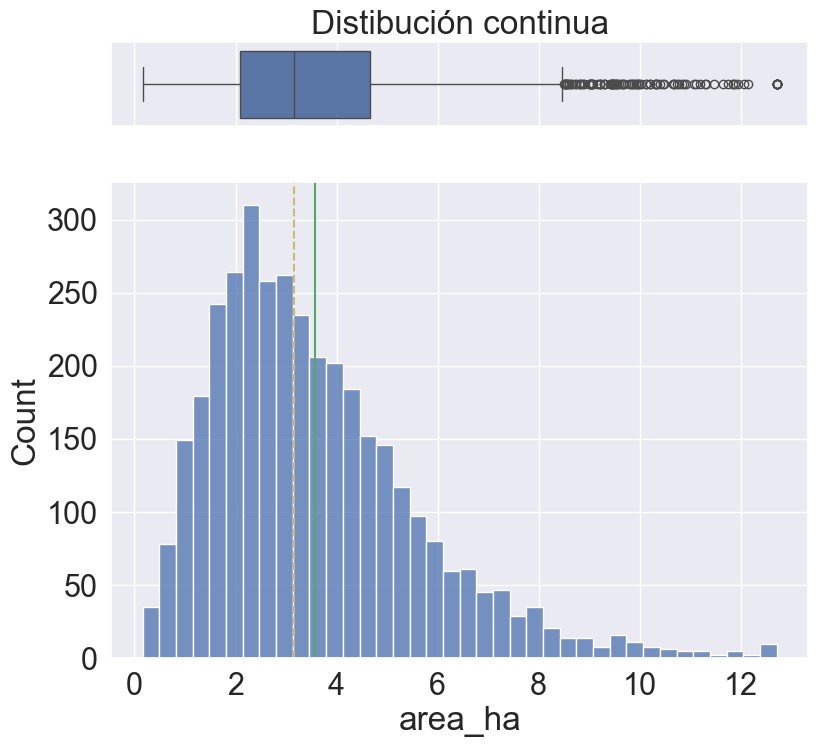

Cont


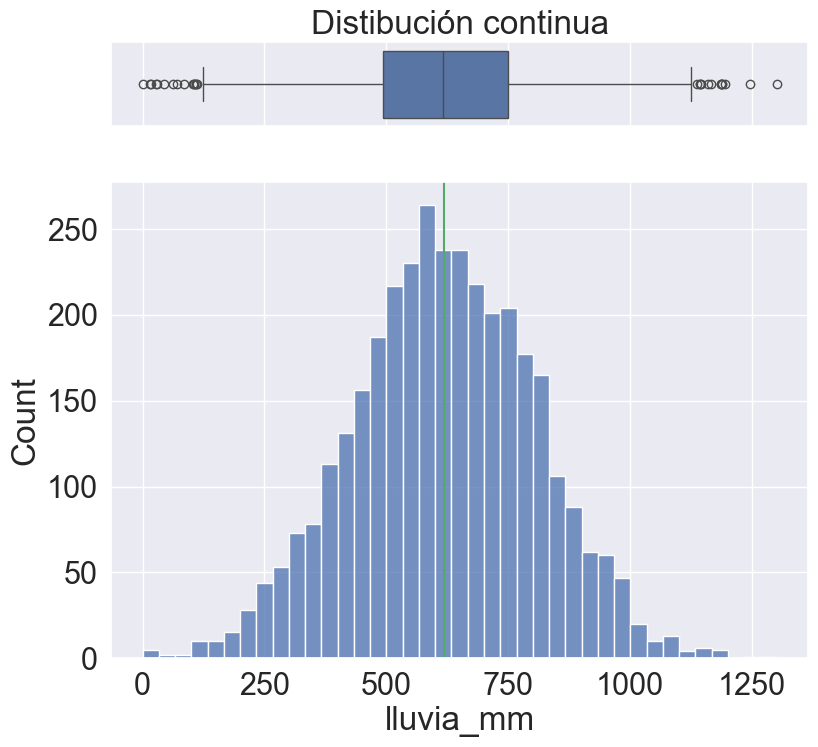

Cont


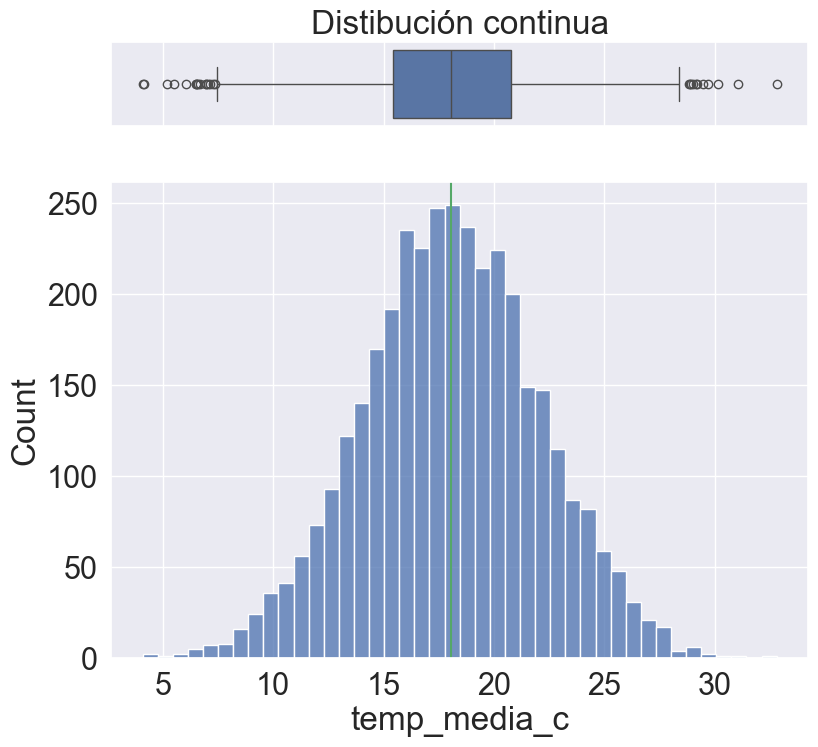

Cont


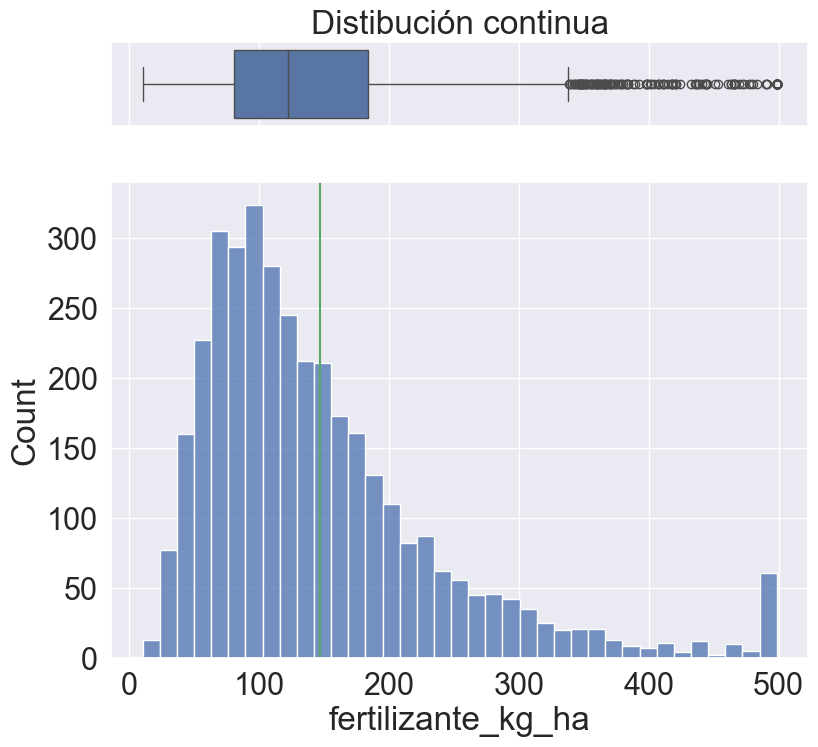

Cont


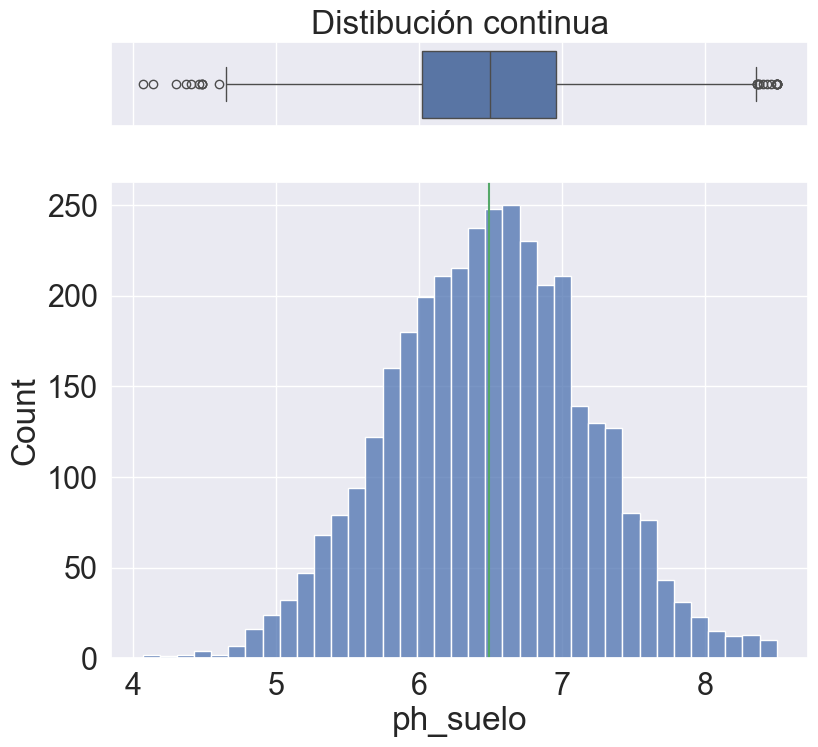

Cont


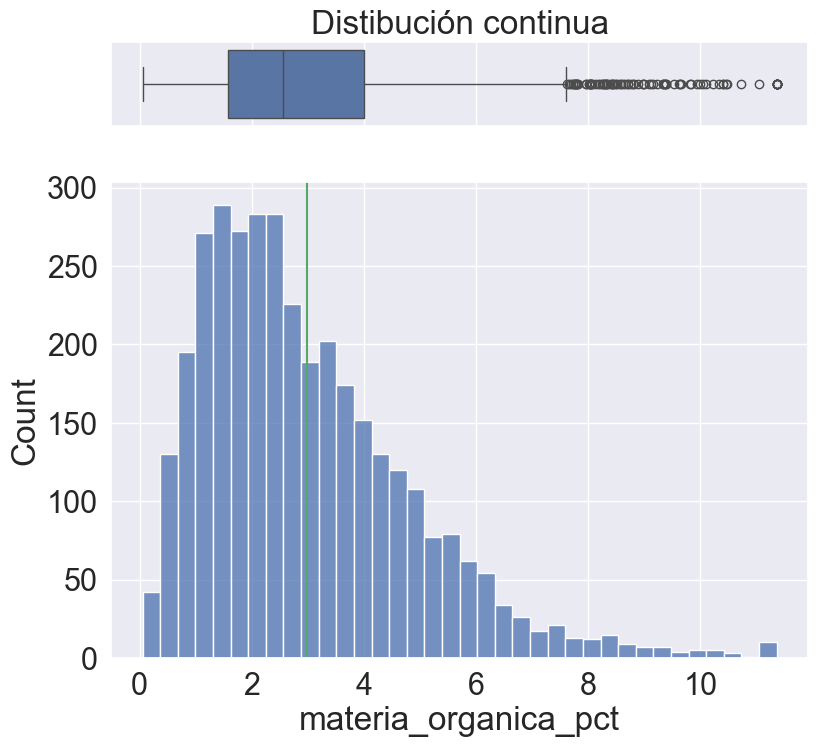

Cont


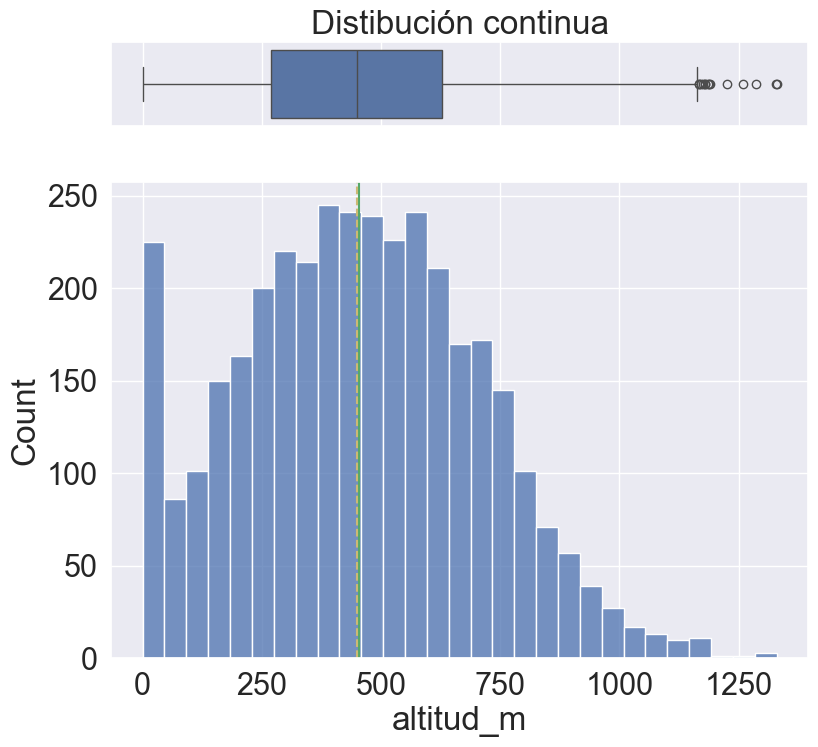

Cont


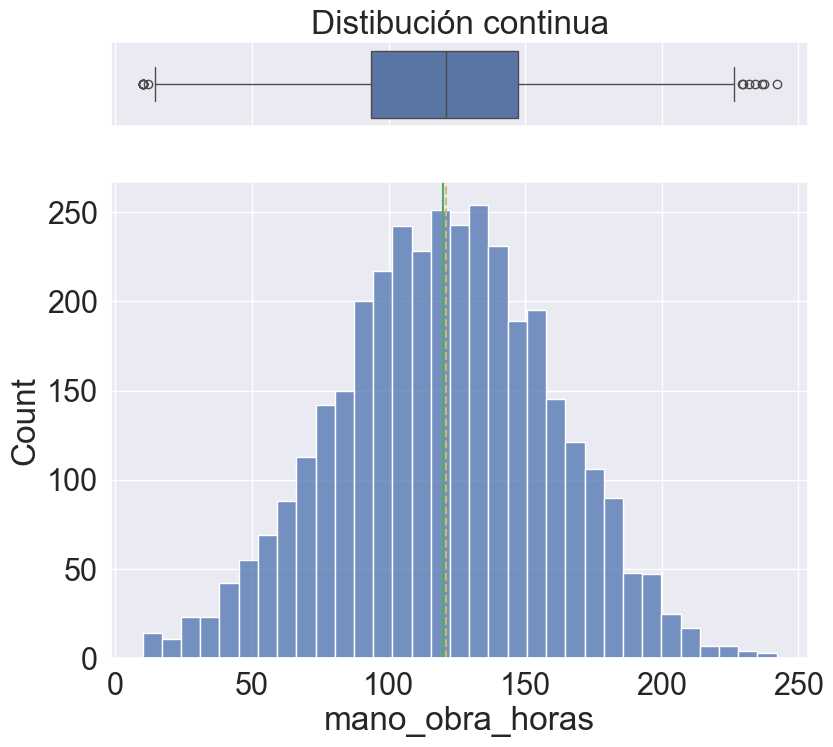

area_ha                 None
lluvia_mm               None
temp_media_c            None
fertilizante_kg_ha      None
ph_suelo                None
materia_organica_pct    None
altitud_m               None
mano_obra_horas         None
dtype: object

In [47]:
#Volvemos a visualizar las variables
imput_cont_wins.apply(plot)

In [48]:
# Unir variables categóricas

imput_wins = imput_cont_wins.join(imput.select_dtypes(exclude=np.number))

imput_wins.head()


,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas
0,1.639907,418.912109,12.947372,80.112469,6.378618,0.961564,564.350321,117.657884,Si,Franco,V1,Alto,Nunca
1,3.181230,829.883681,13.273468,120.907585,6.510040,5.700165,848.351457,118.783270,Si,Franco,V2,Medio,Nunca
2,2.335113,NaN,15.318376,116.182533,6.338459,1.862246,471.860055,158.016439,No,Franco,V1,NaN,Frecuente
3,3.380414,596.452294,21.758124,259.092031,7.016593,7.405093,792.009663,99.675733,No,Arcilloso,V2,Medio,Ocasional
4,2.119452,468.527190,17.286543,116.321076,5.538014,0.371970,359.044071,95.332274,Si,Arenoso,V1,Alto,Frecuente


In [49]:
# Incidencia de missings
imput_wins.apply(lambda x: x.isna().sum()/imput_wins.shape[0]*100)


area_ha                  0.000000
lluvia_mm                3.277778
temp_media_c             0.277778
fertilizante_kg_ha       0.027778
ph_suelo                 1.500000
materia_organica_pct     2.027778
altitud_m                0.000000
mano_obra_horas          0.000000
riego                    0.000000
tipo_suelo               0.000000
variedad_semilla         0.000000
uso_pesticidas          20.000000
historial_plagas         0.000000
dtype: float64

La mayoría de variables tienen muy pocos missing, menos del 5% (algo bueno). Sin embargo, uso_pesticidas tiene un 20%, aunque sigue siendo utilizable, porque normalmente se considera problemático cuando supera 50%.

In [50]:
#Comprobamos los missings por observación
imput_wins['n_missings'] = imput_wins.apply(lambda x: x.isna().sum(), axis=1)

imput_wins.n_missings.describe()


count    3600.000000
mean        0.271111
std         0.475401
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         3.000000
Name: n_missings, dtype: float64

In [51]:
#Vemos el numero de missings
imput_wins.n_missings.value_counts()

n_missings
0    2674
1     877
2      48
3       1
Name: count, dtype: int64

Vemos que la mayoría de las filas no tienen ningún missing (2674) o solo tienen uno (877). Solo unas pocas tienen dos o tres valores faltantes. Por tanto, decidimos no eliminar observaciones y optar por imputar los valores faltantes para mantener el tamaño del dataset.

In [52]:
#Eliminamos la variable auxiliar antes de imputar
imput_wins = imput_wins.drop(columns=['n_missings'])

In [53]:
#Imputamos
#Separamos variables numéricas y categóricas
imput_num = imput_wins.select_dtypes(include=np.number)
imput_cat = imput_wins.select_dtypes(exclude=np.number)

In [54]:
from sklearn.impute import KNNImputer

imput_num = imput_wins.select_dtypes(include=np.number)

imputer_num = KNNImputer(n_neighbors=5)
imput_num_imp = pd.DataFrame(
    imputer_num.fit_transform(imput_num),
    columns=imput_num.columns,
    index=imput_num.index
)

In [55]:
#Imputamos las categóricas por moda
imput_cat = imput_wins.select_dtypes(exclude=np.number).copy()

# Crear categoría explícita para missing en uso_pesticidas
imput_cat['uso_pesticidas'] = imput_cat['uso_pesticidas'].astype('object')
imput_cat['uso_pesticidas'] = imput_cat['uso_pesticidas'].fillna('Desconocido')
imput_cat['uso_pesticidas'] = imput_cat['uso_pesticidas'].astype('category')

# Para el resto de categóricas, imputación por moda si hubiese missing
cat_resto = imput_cat.drop(columns=['uso_pesticidas'])

from sklearn.impute import SimpleImputer

imputer_cat = SimpleImputer(strategy='most_frequent')

cat_resto_imp = pd.DataFrame(
    imputer_cat.fit_transform(cat_resto),
    columns=cat_resto.columns,
    index=cat_resto.index
)

for c in cat_resto_imp.columns:
    cat_resto_imp[c] = cat_resto_imp[c].astype('category')

imput_cat_imp = pd.concat(
    [cat_resto_imp, imput_cat[['uso_pesticidas']]],
    axis=1
)

In [56]:
#Recuperamos tipo category
for c in imput_cat.columns:
    imput_cat_imp[c] = imput_cat_imp[c].astype('category')

In [57]:
#Unimos todo
imput_dep = pd.concat([imput_num_imp, imput_cat_imp], axis=1)

In [58]:
#Comprobamos
imput_dep.isna().sum()

area_ha                 0
lluvia_mm               0
temp_media_c            0
fertilizante_kg_ha      0
ph_suelo                0
materia_organica_pct    0
altitud_m               0
mano_obra_horas         0
riego                   0
tipo_suelo              0
variedad_semilla        0
historial_plagas        0
uso_pesticidas          0
dtype: int64

**Justificación missings**:

Primero analizamos el porcentaje de valores faltantes por variable y por observación. Vemos que la mayoría de variables tienen pocos missing y que la mayoría de filas están completas o tienen como mucho un valor perdido. Por eso decidimos imputar en vez de eliminar observaciones.
Para las variables numéricas usamos imputación por mediana, porque es mejor cuando tenemos frente a valores extremos. Para las variables categóricas usamos imputación por moda.

In [59]:
#Datos depurados
#Unimos el input depurado con las variables objetivo
datos_dep = pd.concat([imput_dep, varObjCont, varObjBin], axis=1)


In [60]:
#Comprobamos
datos_dep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   area_ha               3600 non-null   float64 
 1   lluvia_mm             3600 non-null   float64 
 2   temp_media_c          3600 non-null   float64 
 3   fertilizante_kg_ha    3600 non-null   float64 
 4   ph_suelo              3600 non-null   float64 
 5   materia_organica_pct  3600 non-null   float64 
 6   altitud_m             3600 non-null   float64 
 7   mano_obra_horas       3600 non-null   float64 
 8   riego                 3600 non-null   category
 9   tipo_suelo            3600 non-null   category
 10  variedad_semilla      3600 non-null   category
 11  historial_plagas      3600 non-null   category
 12  uso_pesticidas        3600 non-null   category
 13  rendimiento_kg_ha     3600 non-null   float64 
 14  plaga_severa          3600 non-null   category
dtypes: c

In [61]:
#Comprobamos todos los valores
datos_dep.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
area_ha,3600.0,3.58,2.07,0.16,2.09,3.17,4.65,12.71
lluvia_mm,3600.0,618.34,185.97,0.00,497.84,616.32,746.03,1301.29
temp_media_c,3600.0,18.06,4.01,4.08,15.43,18.04,20.75,32.81
fertilizante_kg_ha,3600.0,146.99,93.82,10.63,81.33,122.52,184.12,498.44
ph_suelo,3600.0,6.49,0.69,4.07,6.02,6.49,6.95,8.50
materia_organica_pct,3600.0,2.99,1.86,0.05,1.60,2.59,3.96,11.36
altitud_m,3600.0,453.83,251.19,0.00,269.10,449.86,627.43,1329.74
mano_obra_horas,3600.0,120.10,39.44,10.00,93.42,120.88,147.47,242.06
rendimiento_kg_ha,3600.0,7112.24,635.76,3444.27,6722.79,7146.02,7547.97,9123.62


**Observaciones**:

Después de tratar los outliers y los missings, el dataset queda completo y sin valores faltantes. Vemos valores razonables para todas las variables y dentro de rangos coherentes. Con la winsorización hemos podido limitar algunos valores extremos sin eliminar observaciones, por lo que mantenemos el tamaño original del dataset.

In [62]:
# Generar aleatorios
#Fijamos la semilla para que se puedan reproducir los resultados
np.random.seed(123)

#Generamos una primera variable aleatoria de control
datos_dep['aleatorio1'] = np.random.uniform(0, 1, size=datos_dep.shape[0])

#Generamos una segunda variable aleatoria de control
datos_dep['aleatorio2'] = np.random.uniform(0, 1, size=datos_dep.shape[0])

In [63]:
#Comprobamos
datos_dep.head()

,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,riego,tipo_suelo,variedad_semilla,historial_plagas,uso_pesticidas,rendimiento_kg_ha,plaga_severa,aleatorio1,aleatorio2
0,1.639907,418.912109,12.947372,80.112469,6.378618,0.961564,564.350321,117.657884,Si,Franco,V1,Nunca,Alto,6320.282655,0,0.696469,0.326178
1,3.181230,829.883681,13.273468,120.907585,6.510040,5.700165,848.351457,118.783270,Si,Franco,V2,Nunca,Medio,8011.839833,1,0.286139,0.391495
2,2.335113,590.335976,15.318376,116.182533,6.338459,1.862246,471.860055,158.016439,No,Franco,V1,Frecuente,Desconocido,6380.726608,1,0.226851,0.767976
3,3.380414,596.452294,21.758124,259.092031,7.016593,7.405093,792.009663,99.675733,No,Arcilloso,V2,Ocasional,Medio,6969.167513,1,0.551315,0.264323
4,2.119452,468.527190,17.286543,116.321076,5.538014,0.371970,359.044071,95.332274,Si,Arenoso,V1,Frecuente,Alto,6416.729743,1,0.719469,0.949718


In [64]:
#Definimos variable objetivo continua
varObjCont = datos_dep['rendimiento_kg_ha']

#Creamos el input eliminando las variables objetivo
imput = datos_dep.drop(['rendimiento_kg_ha','plaga_severa'],axis=1)

In [65]:
#Aplicamos la función al input completo contra la objetivo continua
tablaCramer = pd.DataFrame(imput.apply(lambda x: cramers_v(x,varObjCont)), columns=['VCramer'])

#Ordenamos las variables según su asociación con la respuesta
tablaCramer.sort_values(by='VCramer',ascending=False)

,VCramer
lluvia_mm,0.499677
riego,0.163761
fertilizante_kg_ha,0.107369
temp_media_c,0.083660
tipo_suelo,0.080673
materia_organica_pct,0.061687
ph_suelo,0.052620
area_ha,0.051763
variedad_semilla,0.047645
historial_plagas,0.040351


In [66]:
#Gráfico de importancia de las variables frente a la objetivo

import plotly.express as px

px.bar(tablaCramer, x=tablaCramer.VCramer, title="Relaciones frente a rendimiento").update_yaxes(categoryorder="total ascending").show()

**Respuesta**:

- Generamos dos variables aleatorias de control y a continuación, calculamos la V de Cramer entre cada predictor y la variable objetivo continua.

- Vemos que destacan lluvia_mm, seguida de riego, fertilizante_kg_ha y temp_media_c, que presentan una asociación mayor con el rendimiento del cultivo (aunque claramente lluvia destaca por encima de todas). Podríamos decir que son candidatas a tener mayor importancia en el modelo.

- Por el contrario, variables como altitud_m, mano_obra_horas o uso_pesticidas presentan niveles de asociación similares o incluso inferiores a los de las variables aleatorias, por lo que su relación con la variable objetivo podría ser débil o espuria.

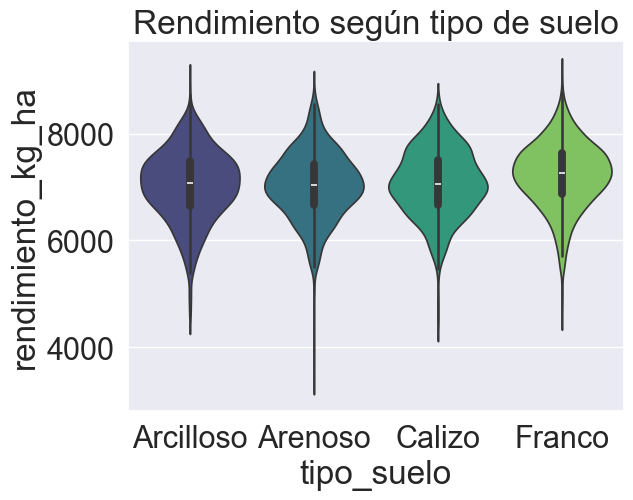

In [67]:
plt.clf()

#Distribución del rendimiento según tipo de suelo
sns.violinplot(x='tipo_suelo', y='rendimiento_kg_ha', data=datos_dep, palette='viridis')

plt.title('Rendimiento según tipo de suelo')
plt.show()

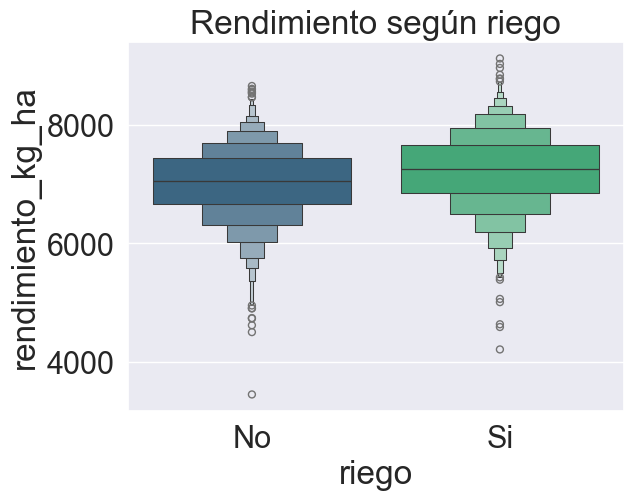

In [68]:
plt.clf()

sns.boxenplot(x='riego', y='rendimiento_kg_ha', data=datos_dep, palette='viridis')

plt.title('Rendimiento según riego')
plt.show()

De forma gráfica también podemos ver algunas relaciones entre variables categóricas y el rendimiento.

En el caso de tipo_suelo vemos ligeras diferencias en la distribución del rendimiento entre los distintos tipos de suelo, y al comparar rendimiento y riego vemos diferencias en la distribución del rendimiento entre parcelas con y sin riego, lo que resulta coherente con los resultados del ranking de V de Cramer, donde las variables relacionadas con el agua (lluvia y riego) mostraban mayor asociación con el rendimiento.

<Figure size 640x480 with 0 Axes>

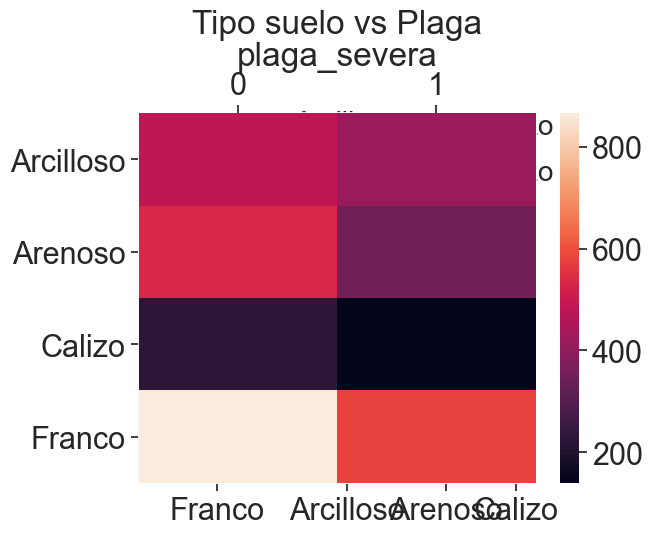

In [69]:
from statsmodels.graphics.mosaicplot import mosaic
plt.clf()

#Mosaic plot entre tipo de suelo y presencia de plaga severa
mosaic(datos_dep, ['tipo_suelo','plaga_severa'],gap=0.005,title='Tipo suelo vs Plaga')

#Heatmap de la tabla de contingencia
sns.heatmap(pd.crosstab(datos_dep.tipo_suelo,datos_dep.plaga_severa))

plt.show()

<Figure size 640x480 with 0 Axes>

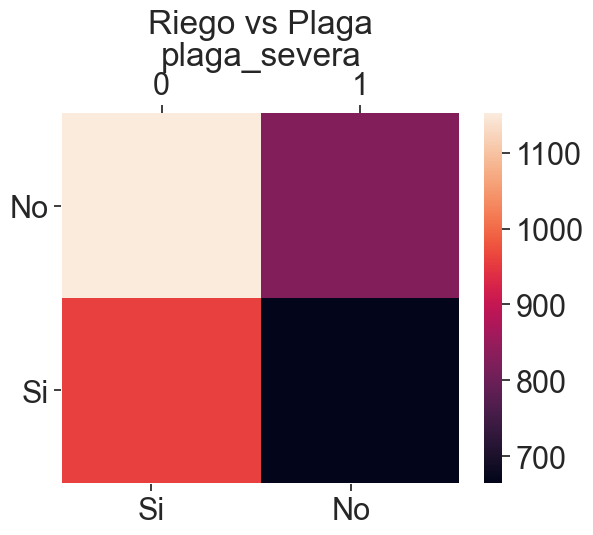

In [70]:
plt.clf()

# Mosaic entre riego y plaga severa
mosaic(datos_dep, ['riego','plaga_severa'],gap=0.005,title='Riego vs Plaga')

sns.heatmap(pd.crosstab(datos_dep.riego,datos_dep.plaga_severa))

plt.show()

Vemos también vemos diferencias entre categorías. En el caso de tipo_suelo, vemos diferencias en la presencia de plaga severa entre los distintos tipos de suelo. De forma similar, en la gráfica riego vs plaga_severa observamos diferencias entre parcelas con y sin riego, por lo que podemos pensar que esta variable podría estar relacionada con la aparición de plagas.

In [71]:
#Definimos la variable objetivo continua
varObjCont = datos_dep['rendimiento_kg_ha']

In [72]:
import statsmodels.formula.api as smf

#Ajustamos el modelo completo
modelo_completo = smf.ols(formula = 'rendimiento_kg_ha ~ area_ha + lluvia_mm + temp_media_c + fertilizante_kg_ha + ph_suelo + materia_organica_pct + altitud_m + mano_obra_horas + C(riego) + C(tipo_suelo) + C(variedad_semilla) + C(uso_pesticidas) + C(historial_plagas)', data = datos_dep).fit()


In [73]:
modelo_completo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     1107.
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        17:53:05   Log-Likelihood:                -24795.
No. Observations:                3600   AIC:                         4.963e+04
Df Residuals:                    3579   BIC:                         4.976e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                         4212.5273     50.999     82.600      0.000    4112.537    4312.517
C(riego)[T.Si]                     220.4548      7.982     27.620      0.000     204.806     236.104
C(tipo_suelo)[T.Arenoso]            -4.4991     11.260     -0.400      0.689     -26.575      17.577
C(tipo_suelo)[T.Calizo]             12.3127     14.753      0.835      0.404     -16.612      41.237
C(tipo_suelo)[T.Franco]            155.4874     10.116     15.371      0.000     135.654     175.321
C(variedad_semilla)[T.V2]           17.4784     10.346      1.689      0.091      -2.807      37.764
C(variedad_semilla)[T.V3]            2.8169     11.149      0.253      0.801     -19.042      24.676
C(variedad_semilla)[T.V4]          135.0699     13.187     10.243      0.000     109.215     160.925
C(uso_pesticidas)[T.Bajo]           11.3689     12.948      0.878      0.380     -14.018      36.756
C(uso_pesticidas)[T.Desconocido]     7.4229     14.333      0.518      0.605     -20.680      35.526
C(uso_pesticidas)[T.Medio]          25.6793     13.477      1.905      0.057      -0.744      52.103
C(historial_plagas)[T.Nunca]       -21.8513     13.329     -1.639      0.101     -47.985       4.282
C(historial_plagas)[T.Ocasional]   -10.6286     14.303     -0.743      0.457     -38.672      17.415
area_ha                              0.5080      1.917      0.265      0.791      -3.250       4.266
lluvia_mm                            2.9060      0.021    136.063      0.000       2.864       2.948
temp_media_c                        29.2184      0.991     29.474      0.000      27.275      31.162
fertilizante_kg_ha                   1.2333      0.042     29.126      0.000       1.150       1.316
ph_suelo                             6.6502      5.791      1.148      0.251      -4.704      18.004
materia_organica_pct                43.3629      2.131     20.349      0.000      39.185      47.541
altitud_m                            0.0141      0.016      0.888      0.375      -0.017       0.045
mano_obra_horas                      0.2351      0.101      2.334      0.020       0.038       0.433
==============================================================================
Omnibus:                      395.946   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2929.569
Skew:                          -0.238   Prob(JB):                         0.00
Kurtosis:                       7.394   Cond. No.                     1.07e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.07e+04. This might indicate that there are
stron

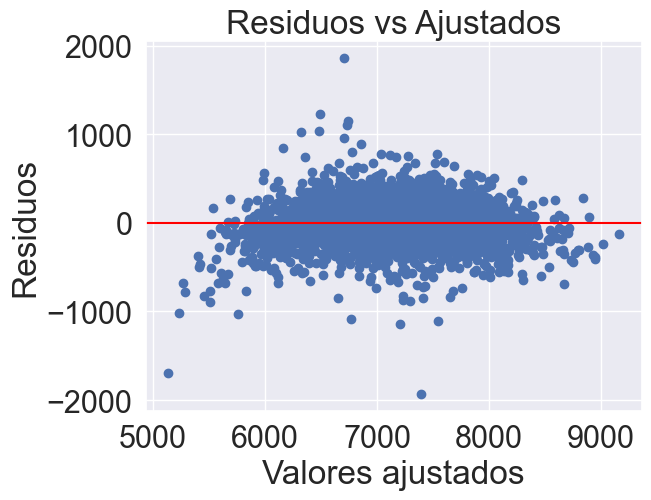

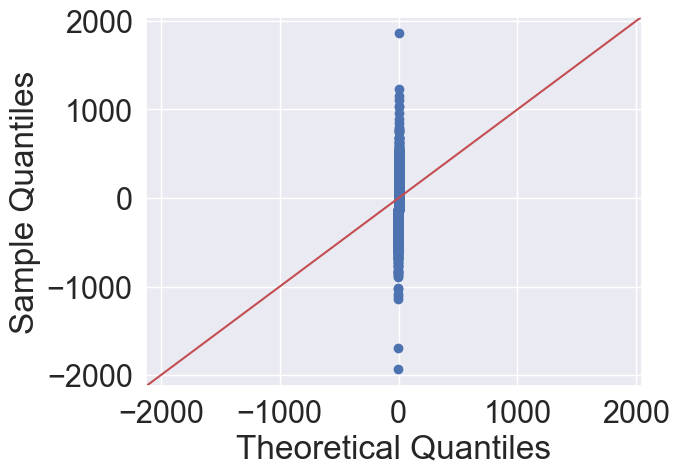

In [74]:
#Residuos vs ajustados
plt.scatter(modelo_completo.fittedvalues, modelo_completo.resid)
plt.axhline(0, color='red')
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs Ajustados")
plt.show()

#QQ-plot
sm.qqplot(modelo_completo.resid, line='45')
plt.show()

**Respuestas**:

- El coeficiente de determinación del modelo es R2=0.869,es decir, el modelo es capaz de explicar aproximadamente el 86.9% de la variabilidad del rendimiento (rendimiento_kg_ha) a partir de las variables explicativas incluidas en el modelo. Por tanto, el modelo presenta una capacidad explicativa elevada, ya que queda aproximadamente un 13.1% de la variabilidad sin explicar, posiblemente debido a factores no incluidos en el modelo o a ruido aleatorio.
- El contraste general del modelo plantea como hipótesis nula que todos los coeficientes de las variables explicativas son iguales a cero, es decir, que ninguna variable del modelo tiene relación con el rendimiento. Como el p-value del estadístico F es prácticamente 0, se rechaza la hipótesis nula al nivel de significación α=0.05. En este caso, esto indica que el modelo es globalmente significativo y que al menos una de las variables explicativas sí está relacionada con el rendimiento.
- El modelo tiene 19 efectos sin contar la constante. De ellos, 9 son significativos, ya que presentan un p-value inferior a 0.05.
- En el análisis residual, el valor de Durbin-Watson es 1.994, muy cercano a 2, lo que nos sugiere que no hay autocorrelación en los residuos. Por otro lado, los tests Omnibus y Jarque-Bera tienen p-values muy bajos, por lo que indican que los residuos no siguen exactamente una distribución normal. Aun así, el modelo presenta un ajuste alto y, dado el tamaño de la muestra, esta falta de normalidad estricta no impide que podamos considerar esta modelo como útil para la predicción.

In [75]:
import statsmodels.api as sm
from sklearn import linear_model
from statsmodels.formula.api import ols
import pandas as pd

In [76]:
#Input sin objetivos
imput = datos_dep.drop(['rendimiento_kg_ha', 'plaga_severa'], axis=1)

In [77]:
#Quitamos los aleatorios
imput = imput.loc[:, ~imput.columns.str.contains('aleatorio', case=False)]

In [78]:
#Matriz de diseño explícita
imput_dummy = pd.get_dummies(imput, columns=['riego', 'tipo_suelo', 'variedad_semilla', 'uso_pesticidas', 'historial_plagas'], drop_first=False)

In [79]:
#Borramos niveles de referencia
imput_dummy.drop(['riego_No', 'tipo_suelo_Arenoso', 'variedad_semilla_Estandar', 'uso_pesticidas_Bajo', 'historial_plagas_No'], axis=1, inplace=True, errors='ignore')

In [80]:
#Añadimos constante
imput_dummy = sm.add_constant(imput_dummy)

imput_dummy.head()

,const,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,riego_Si,...,variedad_semilla_V1,variedad_semilla_V2,variedad_semilla_V3,variedad_semilla_V4,uso_pesticidas_Alto,uso_pesticidas_Desconocido,uso_pesticidas_Medio,historial_plagas_Frecuente,historial_plagas_Nunca,historial_plagas_Ocasional
0,1.0,1.639907,418.912109,12.947372,80.112469,6.378618,0.961564,564.350321,117.657884,True,...,True,False,False,False,True,False,False,False,True,False
1,1.0,3.181230,829.883681,13.273468,120.907585,6.510040,5.700165,848.351457,118.783270,True,...,False,True,False,False,False,False,True,False,True,False
2,1.0,2.335113,590.335976,15.318376,116.182533,6.338459,1.862246,471.860055,158.016439,False,...,True,False,False,False,False,True,False,True,False,False
3,1.0,3.380414,596.452294,21.758124,259.092031,7.016593,7.405093,792.009663,99.675733,False,...,False,True,False,False,False,False,True,False,False,True
4,1.0,2.119452,468.527190,17.286543,116.321076,5.538014,0.371970,359.044071,95.332274,True,...,True,False,False,False,True,False,False,True,False,False


In [81]:
from sklearn import linear_model

#Lasso
reg = linear_model.LassoLarsIC(criterion='bic')
reg.fit(imput_dummy, varObjCont)

,"criterion criterion: {'aic', 'bic'}, default='aic'The type of criterion to use.",'bic'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"verbose verbose: bool or int, default=FalseSets the verbosity amount.",False
,"precompute precompute: bool, 'auto' or array-like, default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=500Maximum number of iterations to perform. Can be used forearly stopping.",500
,"eps eps: float, default=np.finfo(float).epsThe machine-precision regularization in the computation of theCholesky diagonal factors. Increase this for very ill-conditionedsystems. Unlike the ``tol`` parameter in some iterativeoptimization-based algorithms, this parameter does not controlthe tolerance of the optimization.",np.float64(2....049250313e-16)
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"positive positive: bool, default=FalseRestrict coefficients to be >= 0. Be aware that you might want toremove fit_intercept which is set True by default.Under the positive restriction the model coefficients do not convergeto the ordinary-least-squares solution for small values of alpha.Only coefficients up to the smallest alpha value (``alphas_[alphas_ >0.].min()`` when fit_path=True) reached by the stepwise Lars-Lassoalgorithm are typically in congruence with the solution of thecoordinate descent Lasso estimator.As a consequence using LassoLarsIC only makes sense for problems wherea sparse solution is expected and/or reached.",False
,"noise_variance noise_variance: float, default=NoneThe estimated noise variance of the data. If `None`, an unbiasedestimate is computed by an OLS model. However, it is only possiblein the case where `n_samples > n_features + fit_intercept`... versionadded:: 1.1",None


In [82]:
print("Coeficientes estimados por Lasso:", reg.coef_)

Coeficientes estimados por Lasso: [0.00000000e+00 0.00000000e+00 2.90643338e+00 2.91021522e+01
 1.23666638e+00 0.00000000e+00 4.24602406e+01 1.34641048e-02
 2.19583459e-01 2.05799651e+02 0.00000000e+00 0.00000000e+00
 1.40096499e+02 0.00000000e+00 0.00000000e+00 0.00000000e+00
 9.71091426e+01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]


In [83]:
selec_feats = imput_dummy.columns[(reg.coef_ != 0).ravel().tolist()]
print("Variables seleccionadas por Lasso:")
print(selec_feats)

Variables seleccionadas por Lasso:
Index(['lluvia_mm', 'temp_media_c', 'fertilizante_kg_ha',
       'materia_organica_pct', 'altitud_m', 'mano_obra_horas', 'riego_Si',
       'tipo_suelo_Franco', 'variedad_semilla_V4'],
      dtype='object')


In [84]:
#Ajuste con ols
from statsmodels.formula.api import ols

modelo_lasso = ols('rendimiento_kg_ha ~ lluvia_mm + temp_media_c + fertilizante_kg_ha + ''materia_organica_pct + altitud_m + mano_obra_horas + ''C(riego) + C(tipo_suelo) + C(variedad_semilla)', data=datos_dep).fit()

modelo_lasso.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     1701.
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        17:53:05   Log-Likelihood:                -24800.
No. Observations:                3600   AIC:                         4.963e+04
Df Residuals:                    3586   BIC:                         4.971e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                  4252.2947     29.870    142.359      0.000    4193.730    4310.859
C(riego)[T.Si]              220.8881      7.979     27.685      0.000     205.245     236.531
C(tipo_suelo)[T.Arenoso]     -4.3788     11.261     -0.389      0.697     -26.457      17.699
C(tipo_suelo)[T.Calizo]      11.9689     14.748      0.812      0.417     -16.947      40.885
C(tipo_suelo)[T.Franco]     155.0338     10.114     15.329      0.000     135.205     174.863
C(variedad_semilla)[T.V2]    17.2652     10.338      1.670      0.095      -3.003      37.534
C(variedad_semilla)[T.V3]     3.4009     11.139      0.305      0.760     -18.439      25.241
C(variedad_semilla)[T.V4]   135.3994     13.183     10.271      0.000     109.553     161.246
lluvia_mm                     2.9070      0.021    136.116      0.000       2.865       2.949
temp_media_c                 29.3041      0.990     29.589      0.000      27.362      31.246
fertilizante_kg_ha            1.2345      0.042     29.152      0.000       1.151       1.318
materia_organica_pct         43.5614      2.129     20.459      0.000      39.387      47.736
altitud_m                     0.0148      0.016      0.937      0.349      -0.016       0.046
mano_obra_horas               0.2256      0.101      2.240      0.025       0.028       0.423
==============================================================================
Omnibus:                      393.908   Durbin-Watson:                   2.004
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2922.020
Skew:                          -0.232   Prob(JB):                         0.00
Kurtosis:                       7.389   Cond. No.                     6.29e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.29e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

- El modelo presenta un R2 de 0.869. Este valor es prácticamente igual al del modelo completo, por lo que la selección realizada mediante Lasso permite obtener un modelo más sencillo sin pérdida apreciable de capacidad explicativa.
- El modelo incluye 13 efectos (sin contar la constante), de los cuales 9 resultan estadísticamente significativos al nivel de significación α=0.05.
- Variable continua (lluvia_mm): su coeficiente estimado es aproximadamente 2.93. Esto indica que, manteniendo constantes el resto de variables, un incremento de 1 mm en la lluvia se asocia con un aumento medio de aproximadamente 2.93 kg/ha en el rendimiento.
- Variable categórica (riego): el coeficiente de la categoría C(riego)[T.Si] es aproximadamente 221.6. Esto indica que las parcelas con riego presentan, en promedio, un rendimiento aproximadamente 221.6 kg/ha superior al de las parcelas sin riego (categoría de referencia), manteniendo constantes el resto de variables.

In [85]:
#Generamos transformaciones de las variables continuas
transf_cor = imput.select_dtypes(include=np.number).apply(lambda x: mejorTransf(x,varObjCont,tipo='cor'))
transf_cor_names = imput.select_dtypes(include=np.number).apply(lambda x: mejorTransf(x,varObjCont,tipo='cor', name=True))

In [86]:
#Asignamos nombres a las transformadas
transf_cor.columns = transf_cor_names.values
transf_cor.head()

,area_ha_exp,lluvia_mm_raiz4,temp_media_c_sqr,fertilizante_kg_ha_raiz4,ph_suelo_exp,materia_organica_pct_ident,altitud_m_cuarta,mano_obra_horas_sqr
0,2.041023,1.225145,4.891348,0.927722,29.148867,0.488182,25.499865,7.455483
1,4.291511,1.453479,5.257881,1.041277,35.306450,3.031800,130.202746,7.612161
2,2.853831,1.334843,7.858228,1.029940,27.490820,0.971656,12.462661,14.092736
3,4.724117,1.338287,19.448993,1.275720,73.903667,3.946982,98.910519,5.172975
4,2.571981,1.259911,10.852747,1.030278,8.555529,0.171696,4.178092,4.684023


In [87]:
#Unimos al input de predictores
imput_transf = imput.reset_index(drop=True).join(transf_cor)
imput_transf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   area_ha                     3600 non-null   float64 
 1   lluvia_mm                   3600 non-null   float64 
 2   temp_media_c                3600 non-null   float64 
 3   fertilizante_kg_ha          3600 non-null   float64 
 4   ph_suelo                    3600 non-null   float64 
 5   materia_organica_pct        3600 non-null   float64 
 6   altitud_m                   3600 non-null   float64 
 7   mano_obra_horas             3600 non-null   float64 
 8   riego                       3600 non-null   category
 9   tipo_suelo                  3600 non-null   category
 10  variedad_semilla            3600 non-null   category
 11  historial_plagas            3600 non-null   category
 12  uso_pesticidas              3600 non-null   category
 13  area_ha_exp       

In [88]:
#Creamos la matriz de diseño explícita
imput_dummy_transf = pd.get_dummies(imput_transf, columns=['riego', 'tipo_suelo', 'variedad_semilla', 'uso_pesticidas', 'historial_plagas'], drop_first=False)

In [89]:
#Borramos niveles de referencia
imput_dummy_transf.drop(['riego_No','tipo_suelo_Arenoso', 'variedad_semilla_Estandar', 'uso_pesticidas_Bajo','historial_plagas_No'], axis=1, inplace=True, errors='ignore')

In [90]:
#Añadimos constante
imput_dummy_transf = sm.add_constant(imput_dummy_transf)
imput_dummy_transf.head()

,const,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,area_ha_exp,...,variedad_semilla_V1,variedad_semilla_V2,variedad_semilla_V3,variedad_semilla_V4,uso_pesticidas_Alto,uso_pesticidas_Desconocido,uso_pesticidas_Medio,historial_plagas_Frecuente,historial_plagas_Nunca,historial_plagas_Ocasional
0,1.0,1.639907,418.912109,12.947372,80.112469,6.378618,0.961564,564.350321,117.657884,2.041023,...,True,False,False,False,True,False,False,False,True,False
1,1.0,3.181230,829.883681,13.273468,120.907585,6.510040,5.700165,848.351457,118.783270,4.291511,...,False,True,False,False,False,False,True,False,True,False
2,1.0,2.335113,590.335976,15.318376,116.182533,6.338459,1.862246,471.860055,158.016439,2.853831,...,True,False,False,False,False,True,False,True,False,False
3,1.0,3.380414,596.452294,21.758124,259.092031,7.016593,7.405093,792.009663,99.675733,4.724117,...,False,True,False,False,False,False,True,False,False,True
4,1.0,2.119452,468.527190,17.286543,116.321076,5.538014,0.371970,359.044071,95.332274,2.571981,...,True,False,False,False,True,False,False,True,False,False


In [91]:
!pip install mlxtend

  Using cached numpy-2.4.4-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.9-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
Using cached matplotlib-3.10.9-cp313-cp313-macosx_11_0_arm64.whl (8.2 MB)
Using cached numpy-2.4.4-cp313-cp313-macosx_14_0_arm64.whl (5.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.3
    Uninstalling numpy-2.1.3:
      Successfully uninstalled numpy-2.1.3
  Attempting uninstall: matplotlib━━━━━━━━━━━━━━ 0/2 [numpy]
    Found existing installation: matplotlib 3.10.00/2 [numpy]
    Uninstalling matplotlib-3.10.0:━━━━━━━━━ 0/2 [numpy]
      Successfully uninstalled matplotlib-3.10.0━━━━━━━━━━━━━━━━━━ 1/2 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [matplotlib]2 [matplotlib]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.1 requires m

In [92]:
#Aplicamos sfs
from sklearn.linear_model import LinearRegression
from mlxtend.feature_selection import SequentialFeatureSelector as sfs

imput_dummy_transf = imput_dummy_transf.astype(float)
varObjCont = varObjCont.astype(float)

clf = LinearRegression()

sfs_back = sfs(
    clf,
    k_features='parsimonious',
    forward=False,
    floating=False,
    scoring='r2',
    cv=5,
    n_jobs=1
)

sfs_back = sfs_back.fit(imput_dummy_transf, varObjCont)

print(sfs_back.k_feature_names_)
print(sfs_back.k_score_)

('lluvia_mm', 'temp_media_c', 'ph_suelo', 'lluvia_mm_raiz4', 'fertilizante_kg_ha_raiz4', 'ph_suelo_exp', 'materia_organica_pct_ident', 'riego_Si', 'tipo_suelo_Franco', 'variedad_semilla_V4')
0.8865498853514151


In [93]:
pd.DataFrame.from_dict(sfs_back.get_metric_dict()).T

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
31,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.8871184953239794, 0.8920548790754927, 0.869...",0.886061,"(const, area_ha, lluvia_mm, temp_media_c, fert...",0.014428,0.011226,0.005613
30,"(0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14...","[0.8872256076835234, 0.8921426674193301, 0.869...",0.886209,"(const, area_ha, lluvia_mm, temp_media_c, fert...",0.014317,0.011139,0.005569
29,"(0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14...","[0.887247428658129, 0.8924288142473424, 0.8695...",0.886358,"(const, area_ha, lluvia_mm, temp_media_c, fert...",0.014335,0.011153,0.005577
28,"(0, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 1...","[0.8874968600082126, 0.892429561622194, 0.8698...",0.886478,"(const, lluvia_mm, temp_media_c, fertilizante_...",0.014312,0.011136,0.005568
27,"(0, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 1...","[0.8874421908384397, 0.8925249851450273, 0.870...",0.886581,"(const, lluvia_mm, temp_media_c, fertilizante_...",0.014127,0.010991,0.005496
26,"(0, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 1...","[0.8876314433753592, 0.8925351202176196, 0.870...",0.886675,"(const, lluvia_mm, temp_media_c, fertilizante_...",0.013986,0.010882,0.005441
25,"(0, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 1...","[0.8878114098974065, 0.8926238550935569, 0.870...",0.886777,"(const, lluvia_mm, temp_media_c, fertilizante_...",0.013975,0.010873,0.005436
24,"(0, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 1...","[0.8877955161085613, 0.8925772367435129, 0.870...",0.886815,"(const, lluvia_mm, temp_media_c, fertilizante_...",0.013948,0.010852,0.005426
23,"(0, 2, 3, 4, 5, 6, 8, 9, 10, 12, 13, 14, 16, 1...","[0.8876382205429587, 0.8929778797545003, 0.870...",0.886846,"(const, lluvia_mm, temp_media_c, fertilizante_...",0.013944,0.010849,0.005424
22,"(0, 2, 3, 4, 5, 6, 8, 10, 12, 13, 14, 16, 17, ...","[0.8877497246220395, 0.8929718683558887, 0.870...",0.886864,"(const, lluvia_mm, temp_media_c, fertilizante_...",0.013962,0.010863,0.005431


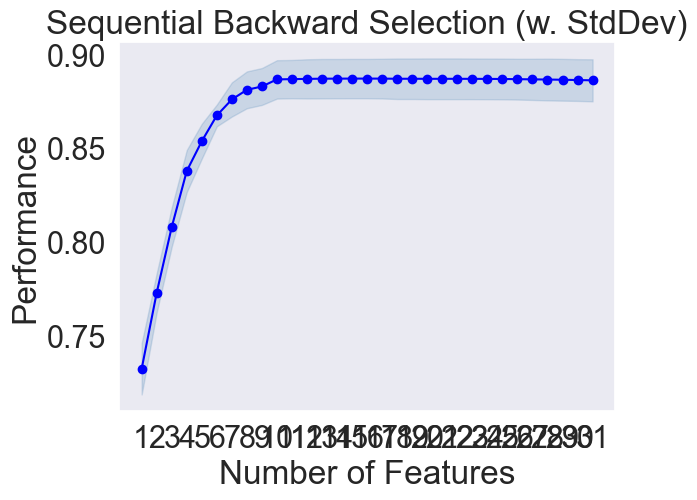

In [94]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
fig1 = plot_sfs(sfs_back.get_metric_dict(), kind='std_dev')
plt.title('Sequential Backward Selection (w. StdDev)')
plt.grid()
plt.show()

In [95]:
#Dataset final con las variables seleccionadas
datos_sfs = imput_dummy_transf[list(sfs_back.k_feature_names_)].copy()
datos_sfs['rendimiento_kg_ha'] = varObjCont.values

In [96]:
#Fórmula final con los efectos seleccionados
formula_sfs = 'rendimiento_kg_ha ~ ' + ' + '.join(sfs_back.k_feature_names_)
print(formula_sfs)

rendimiento_kg_ha ~ lluvia_mm + temp_media_c + ph_suelo + lluvia_mm_raiz4 + fertilizante_kg_ha_raiz4 + ph_suelo_exp + materia_organica_pct_ident + riego_Si + tipo_suelo_Franco + variedad_semilla_V4


In [97]:
#Ajuste final con statsmodels
results_sfs = ols(formula_sfs, data=datos_sfs).fit()


In [98]:
#Resumen del modelo final
results_sfs.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     2836.
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        17:53:13   Log-Likelihood:                -24410.
No. Observations:                3600   AIC:                         4.884e+04
Df Residuals:                    3589   BIC:                         4.891e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                    512.3164    131.361      3.900      0.000     254.766     769.867
lluvia_mm                      1.2648      0.075     16.766      0.000       1.117       1.413
temp_media_c                  29.9620      0.888     33.739      0.000      28.221      31.703
ph_suelo                      92.7633      8.502     10.911      0.000      76.094     109.432
lluvia_mm_raiz4             2751.3551    122.004     22.551      0.000    2512.151    2990.559
fertilizante_kg_ha_raiz4     709.5674     20.115     35.275      0.000     670.129     749.006
ph_suelo_exp                  -1.1080      0.083    -13.287      0.000      -1.271      -0.944
materia_organica_pct_ident    82.3926      3.558     23.154      0.000      75.416      89.369
riego_Si                     223.4461      7.152     31.241      0.000     209.423     237.469
tipo_suelo_Franco            154.6675      7.269     21.278      0.000     140.416     168.919
variedad_semilla_V4          131.2806     10.242     12.818      0.000     111.200     151.361
==============================================================================
Omnibus:                      439.968   Durbin-Watson:                   1.984
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4761.608
Skew:                          -0.019   Prob(JB):                         0.00
Kurtosis:                       8.634   Cond. No.                     3.18e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.18e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [99]:
# Fórmula completa objetivo binaria
formBin = 'plaga_severa ~ area_ha + lluvia_mm + temp_media_c + fertilizante_kg_ha + ph_suelo + materia_organica_pct + altitud_m + mano_obra_horas + aleatorio1 + aleatorio2 + C(riego) + C(tipo_suelo) + C(variedad_semilla) + C(uso_pesticidas) + C(historial_plagas)'

In [100]:
# Ajuste modelo bin
datos_dep['plaga_severa'] = datos_dep['plaga_severa'].astype('int64')

from statsmodels.formula.api import logit

modelo_bin = logit(formBin, data=datos_dep).fit()

Optimization terminated successfully.
         Current function value: 0.597020
         Iterations 5


In [101]:
# Summary modelo completo bin
modelo_bin.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           plaga_severa   No. Observations:                 3600
Model:                          Logit   Df Residuals:                     3577
Method:                           MLE   Df Model:                           22
Date:                Sun, 03 May 2026   Pseudo R-squ.:                  0.1198
Time:                        17:53:13   Log-Likelihood:                -2149.3
converged:                       True   LL-Null:                       -2441.7
Covariance Type:            nonrobust   LLR p-value:                1.337e-109
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -3.4634      0.488     -7.103      0.000      -4.419      -2.508
C(riego)[T.Si]                      -0.0102      0.074     -0.138      0.890      -0.155       0.135
C(tipo_suelo)[T.Arenoso]            -0.3386      0.104     -3.249      0.001      -0.543      -0.134
C(tipo_suelo)[T.Calizo]             -0.4228      0.138     -3.074      0.002      -0.692      -0.153
C(tipo_suelo)[T.Franco]             -0.3290      0.093     -3.528      0.000      -0.512      -0.146
C(variedad_semilla)[T.V2]           -0.0082      0.096     -0.085      0.932      -0.197       0.180
C(variedad_semilla)[T.V3]           -0.0602      0.104     -0.582      0.561      -0.263       0.143
C(variedad_semilla)[T.V4]           -0.0581      0.123     -0.474      0.635      -0.298       0.182
C(uso_pesticidas)[T.Bajo]            0.7189      0.127      5.677      0.000       0.471       0.967
C(uso_pesticidas)[T.Desconocido]     0.7076      0.138      5.109      0.000       0.436       0.979
C(uso_pesticidas)[T.Medio]           0.7718      0.131      5.877      0.000       0.514       1.029
C(historial_plagas)[T.Nunca]        -1.1826      0.124     -9.518      0.000      -1.426      -0.939
C(historial_plagas)[T.Ocasional]    -0.6646      0.132     -5.047      0.000      -0.923      -0.407
area_ha                             -0.0126      0.018     -0.707      0.480      -0.048       0.022
lluvia_mm                            0.0030      0.000     14.216      0.000       0.003       0.003
temp_media_c                         0.0749      0.009      8.011      0.000       0.057       0.093
fertilizante_kg_ha                7.342e-05      0.000      0.188      0.851      -0.001       0.001
ph_suelo                             0.1499      0.054      2.782      0.005       0.044       0.255
materia_organica_pct                -0.2456      0.022    -11.330      0.000      -0.288      -0.203
altitud_m                         4.691e-05      0.000      0.320      0.749      -0.000       0.000
mano_obra_horas                     -0.0004      0.001     -0.398      0.690      -0.002       0.001
aleatorio1                           0.2653      0.127      2.086      0.037       0.016       0.515
aleatorio2                           0.1590      0.130      1.228      0.220      -0.095       0.413
====================================================================================================
"""

In [102]:
#Odds Ratios
or_modelo_bin = np.exp(modelo_bin.params)
print(or_modelo_bin)

Intercept                           0.031322
C(riego)[T.Si]                      0.989839
C(tipo_suelo)[T.Arenoso]            0.712783
C(tipo_suelo)[T.Calizo]             0.655206
C(tipo_suelo)[T.Franco]             0.719643
C(variedad_semilla)[T.V2]           0.991844
C(variedad_semilla)[T.V3]           0.941573
C(variedad_semilla)[T.V4]           0.943567
C(uso_pesticidas)[T.Bajo]           2.052084
C(uso_pesticidas)[T.Desconocido]    2.029044
C(uso_pesticidas)[T.Medio]          2.163570
C(historial_plagas)[T.Nunca]        0.306476
C(historial_plagas)[T.Ocasional]    0.514470
area_ha                             0.987458
lluvia_mm                           1.003004
temp_media_c                        1.077768
fertilizante_kg_ha                  1.000073
ph_suelo                            1.161668
materia_organica_pct                0.782251
altitud_m                           1.000047
mano_obra_horas                     0.999628
aleatorio1                          1.303792
aleatorio2


- La métrica de ajuste es el Pseudo R2=0.1196. Este valor indica que el modelo tiene una capacidad explicativa moderada para predecir la presencia de plaga severa. Además, el modelo es globalmente significativo, ya que el p-value del contraste es prácticamente 0.
En general, el ajuste es aceptable pero mejorable, ya que el modelo no explica completamente la variable objetivo.
- El modelo podría mejorar eliminando variables no significativas, como area_ha, fertilizante_kg_ha, altitud_m o mano_obra_horas. Además, el hecho de que una variable aleatoria (aleatorio1) sea significativa sugiere que puede haber ruido o sobreajuste.

El modelo reducido se obtiene mediante un proceso backward manual: se parte del modelo completo y se eliminan progresivamente los efectos con menor evidencia estadística, siempre comprobando que la pérdida de ajuste sea pequeña. El criterio no es eliminar variables de forma automática sin control, sino buscar un modelo más simple, interpretable y con pseudo-R² similar al completo.

In [103]:
# Formula reducida
formBin_red = 'plaga_severa ~ lluvia_mm + temp_media_c + ph_suelo + materia_organica_pct + C(tipo_suelo) + C(uso_pesticidas) + C(historial_plagas)'

In [104]:
# Ajuste modelo reducido
modelo_bin_red = logit(formBin_red, data=datos_dep).fit()

Optimization terminated successfully.
         Current function value: 0.598009
         Iterations 5


In [105]:
# Summary modelo reducido
modelo_bin_red.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           plaga_severa   No. Observations:                 3600
Model:                          Logit   Df Residuals:                     3587
Method:                           MLE   Df Model:                           12
Date:                Sun, 03 May 2026   Pseudo R-squ.:                  0.1183
Time:                        17:53:13   Log-Likelihood:                -2152.8
converged:                       True   LL-Null:                       -2441.7
Covariance Type:            nonrobust   LLR p-value:                6.165e-116
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -3.3384      0.448     -7.451      0.000      -4.217      -2.460
C(tipo_suelo)[T.Arenoso]            -0.3440      0.104     -3.308      0.001      -0.548      -0.140
C(tipo_suelo)[T.Calizo]             -0.4182      0.137     -3.051      0.002      -0.687      -0.149
C(tipo_suelo)[T.Franco]             -0.3350      0.093     -3.600      0.000      -0.517      -0.153
C(uso_pesticidas)[T.Bajo]            0.7192      0.126      5.689      0.000       0.471       0.967
C(uso_pesticidas)[T.Desconocido]     0.7026      0.138      5.084      0.000       0.432       0.974
C(uso_pesticidas)[T.Medio]           0.7776      0.131      5.933      0.000       0.521       1.034
C(historial_plagas)[T.Nunca]        -1.1835      0.124     -9.550      0.000      -1.426      -0.941
C(historial_plagas)[T.Ocasional]    -0.6617      0.131     -5.039      0.000      -0.919      -0.404
lluvia_mm                            0.0030      0.000     14.212      0.000       0.003       0.003
temp_media_c                         0.0749      0.009      8.030      0.000       0.057       0.093
ph_suelo                             0.1508      0.054      2.807      0.005       0.045       0.256
materia_organica_pct                -0.2461      0.022    -11.370      0.000      -0.289      -0.204
====================================================================================================
"""

Para interpretar el modelo logístico se utilizan odds ratios, calculados como exp(beta). Valores superiores a 1 indican aumento de las odds de plaga severa respecto a la categoría de referencia o por unidad adicional de la variable continua. Valores inferiores a 1 indican reducción de dichas odds.

In [106]:
or_red = np.exp(modelo_bin_red.params)
or_red

Intercept                           0.035492
C(tipo_suelo)[T.Arenoso]            0.708897
C(tipo_suelo)[T.Calizo]             0.658249
C(tipo_suelo)[T.Franco]             0.715319
C(uso_pesticidas)[T.Bajo]           2.052704
C(uso_pesticidas)[T.Desconocido]    2.019084
C(uso_pesticidas)[T.Medio]          2.176262
C(historial_plagas)[T.Nunca]        0.306194
C(historial_plagas)[T.Ocasional]    0.515958
lluvia_mm                           1.002998
temp_media_c                        1.077792
ph_suelo                            1.162763
materia_organica_pct                0.781827
dtype: float64

- En el modelo reducido se mantienen 7 variables explicativas: cuatro continuas (lluvia_mm, temp_media_c, ph_suelo y materia_organica_pct) y tres categóricas (tipo_suelo, uso_pesticidas e historial_plagas).
- El modelo completo tenía un Pseudo R2 de aproximadamente 0.1196, mientras que el modelo reducido presenta un valor de aproximadamente 0.1181. Por tanto, la capacidad de ajuste apenas disminuye, lo que indica que podemos simplificar el modelo eliminando variables poco relevantes sin perder prácticamente capacidad explicativa.
- Para la interpretación de los parámetros, se considera la variable continua lluvia_mm. Su coeficiente positivo indica que, a medida que aumenta la lluvia, aumenta la tendencia o posibilidad de que aparezca una plaga severa, manteniendo constantes el resto de variables.
- Para la variable categórica uso_pesticidas, las categorías Bajo y Medio presentan coeficientes positivos, lo que indica que, en comparación con la categoría de referencia, estas situaciones se asocian con una mayor presencia de plaga severa, manteniendo constantes el resto de variables.

In [107]:
#Lista de fórmulas
list_form = [formBin, formBin_red]

In [108]:
#Aplicamos cross validation a la lista
list_res = pd.DataFrame(map(lambda x: cross_val_log(x, datos_dep, seed=2022), list_form))

Modelo: plaga_severa ~ area_ha + lluvia_mm + temp_media_c + fertilizante_kg_ha + ph_suelo + materia_organica_pct + altitud_m + mano_obra_horas + aleatorio1 + aleatorio2 + C(riego) + C(tipo_suelo) + C(variedad_semilla) + C(uso_pesticidas) + C(historial_plagas)
AUC: 0.714 (0.014)
Modelo: plaga_severa ~ lluvia_mm + temp_media_c + ph_suelo + materia_organica_pct + C(tipo_suelo) + C(uso_pesticidas) + C(historial_plagas)
AUC: 0.720 (0.013)


In [109]:
#Extraemos el dataset y damos formato
results = list_res.T.melt()

#Renombramos columnas
results.columns = ['Modelo','AUC']

#Asignamos nombres a los modelos
results['Modelo'] = results['Modelo'].map({0:'Completo', 1:'Reducido'})

results.head()

,Modelo,AUC
0,Completo,0.711329
1,Completo,0.705712
2,Completo,0.728792
3,Completo,0.703266
4,Completo,0.725739


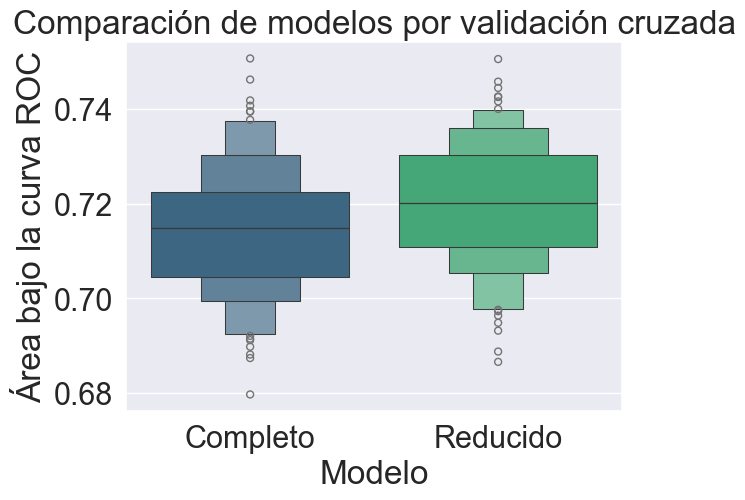

In [110]:
#Boxplots
plt.clf()
sns.boxenplot(x='Modelo', y='AUC', data=results, palette='viridis')
plt.title('Comparación de modelos por validación cruzada')
plt.ylabel('Área bajo la curva ROC')
plt.show()


- El sesgo sería lo lejos que están las predicciones del modelo respecto a la realidad. Cuando un modelo tiene mucho sesgo normalmente es porque es demasiado simple y no consigue captar bien la relación entre las variables.

- La varianza indica cuánto cambian los resultados del modelo cuando se entrena con diferentes grupos de datos. Si la varianza es alta significa que el modelo es inestable y que pequeñas variaciones en los datos pueden cambiar bastante los resultados.

- En los boxplots vemos que los dos modelos presentan valores bastante parecidos, pero el modelo reducido tiene una media ligeramente mayor y una variabilidad muy similar o incluso algo menor. Esto indica que el modelo reducido mantiene prácticamente la misma capacidad de clasificación que el modelo completo, por lo que es preferible utilizarlo, ya que es más simple y utiliza menos variables sin perder capacidad predictiva.


In [111]:
ipi_esp.info()
ipi_esp.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          539 non-null    object 
 1   IPI Nacional  539 non-null    float64
dtypes: float64(1), object(1)
memory usage: 8.6+ KB


,Date,IPI Nacional
0,1975M01,70.658
1,1975M02,72.180
2,1975M03,75.732
3,1975M04,74.844
4,1975M05,74.210


In [112]:
# Conversión a serie temporal

#Hacemos una copia
ipi = ipi_esp.copy()

#Cambiamos la M típica del INE por un guion para generar la fecha correctamente
ipi['Date'] = ipi['Date'].apply(lambda x: x.replace('M','-'))

#Convertimos a serie temporal con la fecha indexada
ipi.set_index(['Date'], inplace=True)
ipi.index = pd.to_datetime(ipi.index)

ipi.head()

,IPI Nacional
Date,
1975-01-01,70.658
1975-02-01,72.180
1975-03-01,75.732
1975-04-01,74.844
1975-05-01,74.210


In [113]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

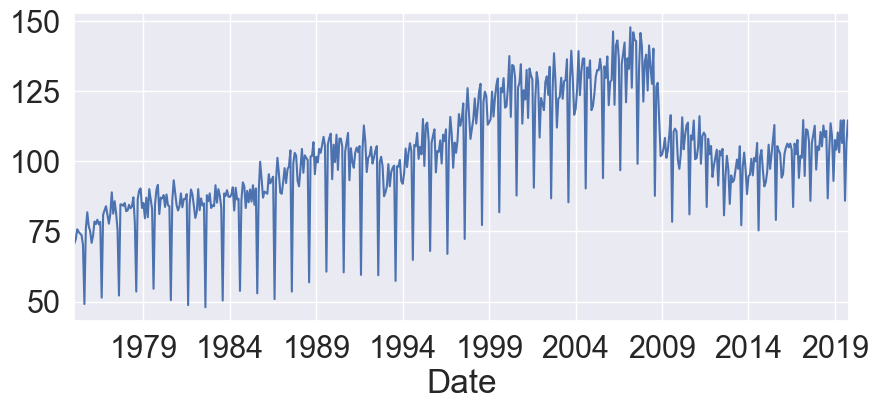

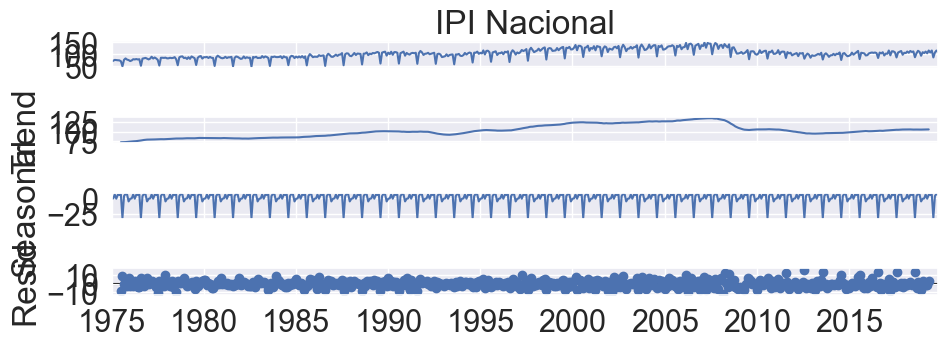

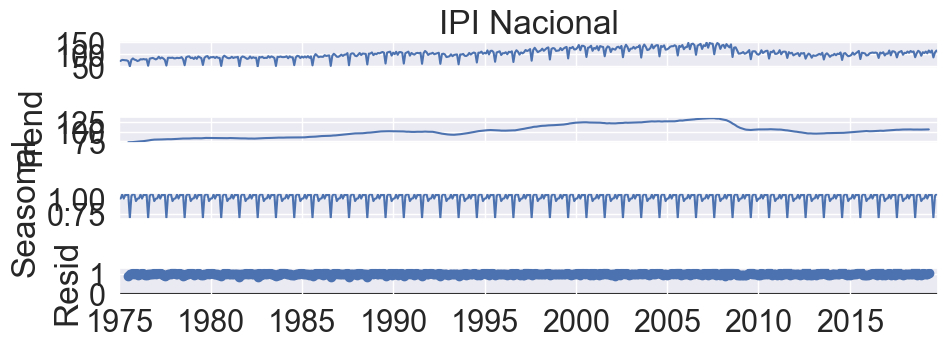

In [114]:
#Componentes

plt.rcParams["figure.figsize"] = (10,4)

ipi['IPI Nacional'].plot()
plt.show()

#Descomposición aditiva
ipi_desc_Ad = seasonal_decompose(ipi['IPI Nacional'], model='additive', period=12)
ipi_desc_Ad.plot()
plt.show()

#Descomposición multiplicativa
ipi_desc_Mul = seasonal_decompose(ipi['IPI Nacional'], model='multiplicative', period=12)
ipi_desc_Mul.plot()
plt.show()

In [115]:
#Prueba de estacionariedad

test_stationarity(ipi['IPI Nacional'])

Results of Dickey-Fuller Test:
Test Statistic                  -1.781256
p-value                          0.389807
#Lags Used                      19.000000
Number of Observations Used    519.000000
Critical Value (1%)             -3.443013
Critical Value (5%)             -2.867125
Critical Value (10%)            -2.569745
dtype: float64


In [116]:
test_stationarity(ipi_desc_Ad.resid.dropna())
test_stationarity(ipi_desc_Mul.resid.dropna())

Results of Dickey-Fuller Test:
Test Statistic                -7.667143e+00
p-value                        1.629782e-11
#Lags Used                     1.500000e+01
Number of Observations Used    5.110000e+02
Critical Value (1%)           -3.443212e+00
Critical Value (5%)           -2.867213e+00
Critical Value (10%)          -2.569791e+00
dtype: float64
Results of Dickey-Fuller Test:
Test Statistic                  -4.618885
p-value                          0.000119
#Lags Used                      16.000000
Number of Observations Used    510.000000
Critical Value (1%)             -3.443237
Critical Value (5%)             -2.867224
Critical Value (10%)            -2.569797
dtype: float64


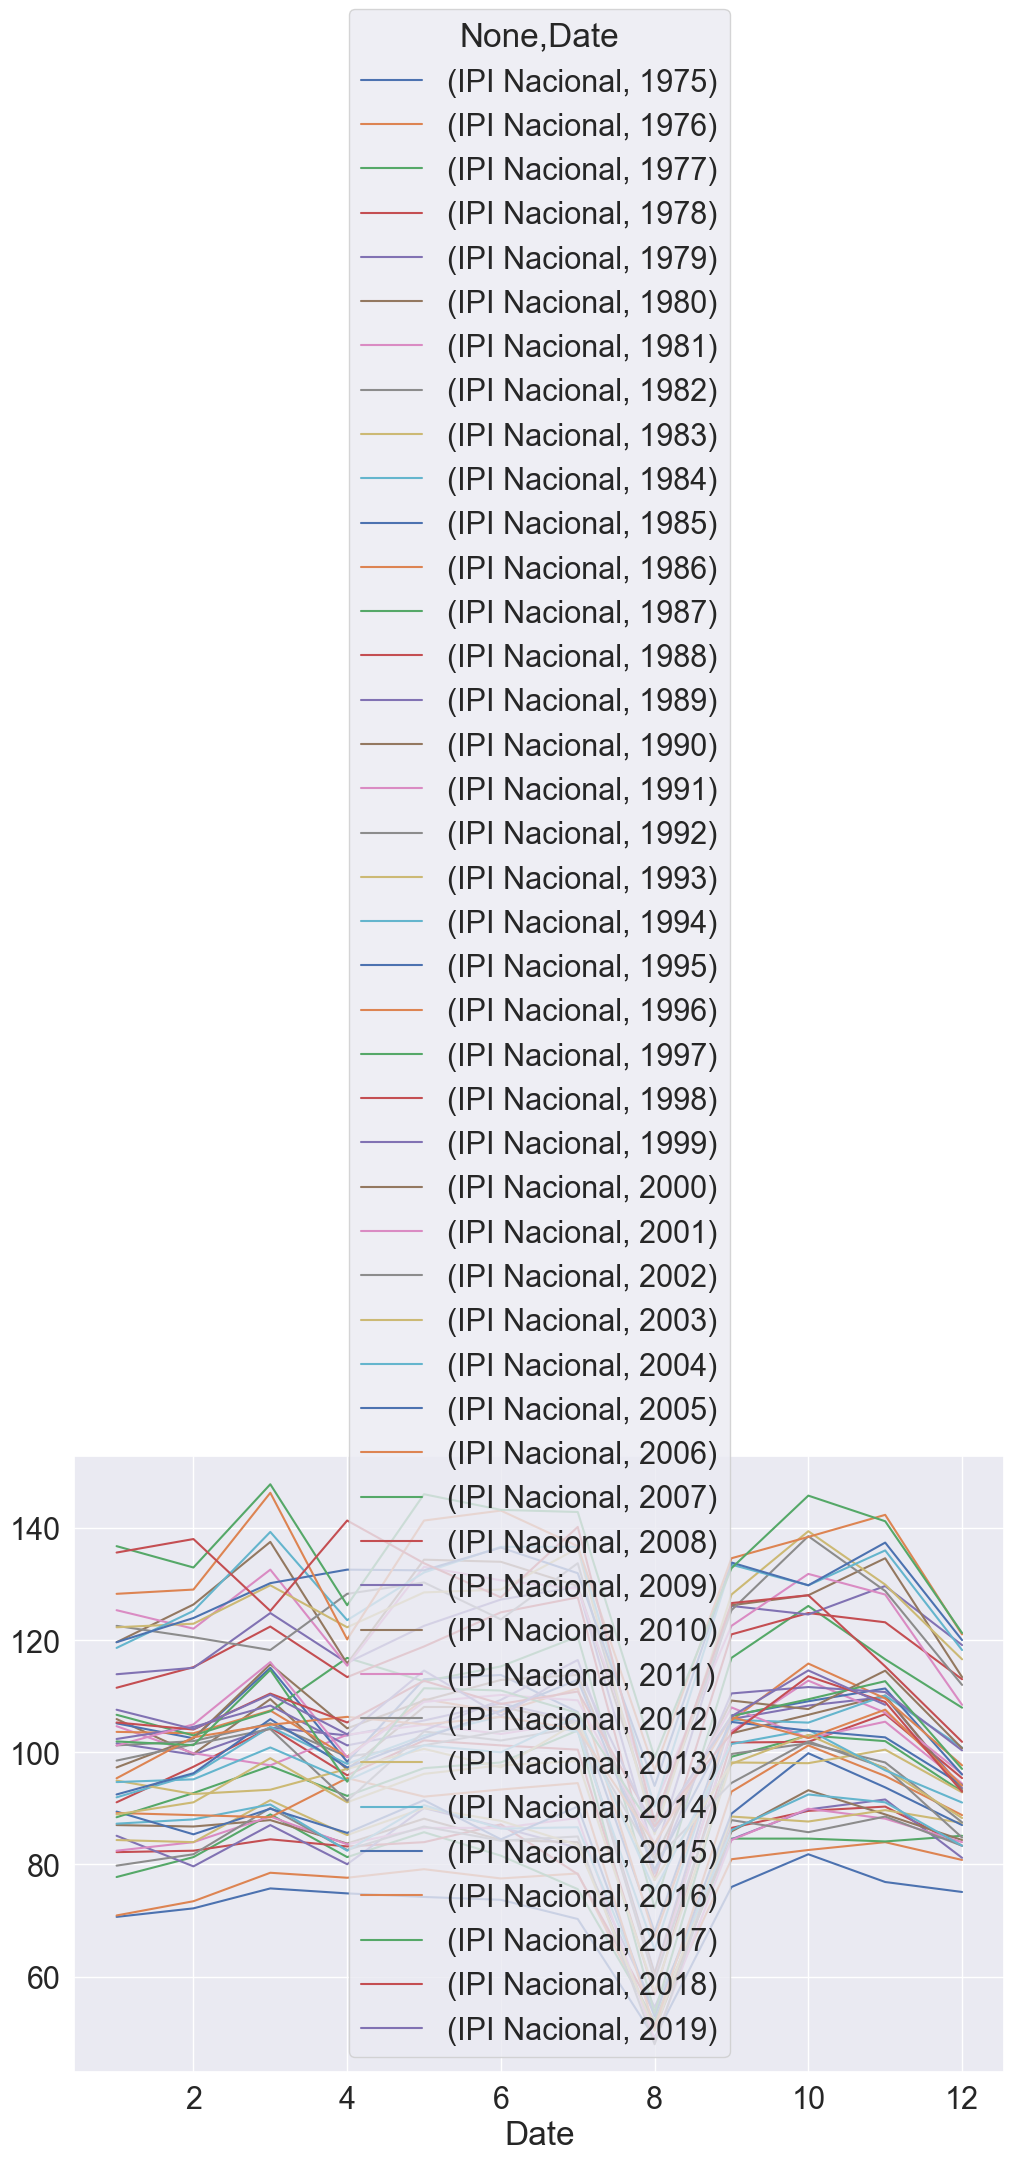

In [117]:
seasonal_plot(ipi, column='IPI Nacional')
plt.show()



- Al representar la serie del IPI Nacional observamos que no se mantiene estable a lo largo del tiempo. En primer lugar aparece una tendencia, ya que el nivel medio del índice cambia con los años: crece durante buena parte del periodo, tiene una caída importante alrededor de la crisis de 2008 y posteriormente muestra cierta recuperación y estabilización. Además, la serie presenta una estacionalidad clara, porque el comportamiento se repite de forma bastante regular cada año. Destaca especialmente una caída muy marcada en el mes de agosto, algo que tiene sentido porque la actividad industrial suele reducirse durante el verano. Las descomposiciones aditiva y multiplicativa muestran estas mismas ideas: una parte de tendencia, una estacionalidad anual bastante marcada y una parte residual que recoge las variaciones que no se explican por esas dos componentes.

- No, la serie no es estacionaria en su forma original. Esto se ve en el gráfico, ya que el nivel medio de la serie cambia con el tiempo y además existe un patrón estacional que se repite cada año. El contraste de Dickey-Fuller confirma esta idea, ya que el p-value obtenido es mayor que 0.05, por lo que no se puede rechazar la hipótesis de que la serie no sea estacionaria. Sin embargo, cuando se eliminan la tendencia y la estacionalidad mediante la descomposición y se analizan los residuos, estos sí resultan estacionarios. Esto indica que la falta de estacionariedad de la serie original se debe principalmente a la presencia de tendencia y estacionalidad.

In [118]:
#Modelo de suavizado adecuado

import statsmodels.tsa.holtwinters as ets
import statsmodels.api as sm
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf

# Partición training-test
ipi_tr = ipi.iloc[:-12]
ipi_tst = ipi.iloc[-12:]

                       ExponentialSmoothing Model Results                       
Dep. Variable:             IPI Nacional   No. Observations:                  527
Model:             ExponentialSmoothing   SSE                           9600.152
Optimized:                         True   AIC                           1561.530
Trend:                         Additive   BIC                           1629.805
Seasonal:                      Additive   AICC                          1562.876
Seasonal Periods:                    12   Date:                 Sun, 03 May 2026
Box-Cox:                          False   Time:                         17:53:32
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.2679367                alpha                 True
smoothing_trend          

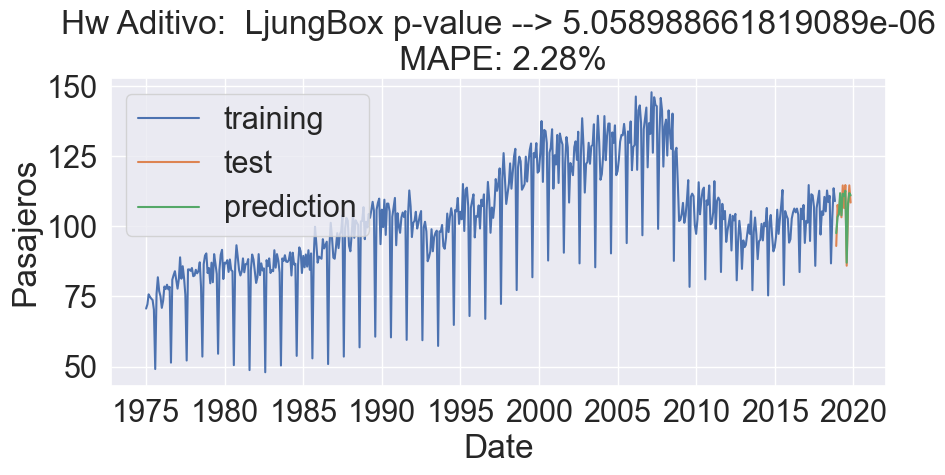

5.058988661819089e-06


In [119]:
#Ajustamos Holt-Winters aditivo
hw_add = ets.ExponentialSmoothing(
    ipi_tr['IPI Nacional'],
    trend='add',
    damped_trend=False,
    seasonal='add',
    seasonal_periods=12
).fit()

print(hw_add.summary())
eval_model(hw_add, ipi_tr['IPI Nacional'], ipi_tst['IPI Nacional'], 'Hw Aditivo')


                       ExponentialSmoothing Model Results                       
Dep. Variable:             IPI Nacional   No. Observations:                  527
Model:             ExponentialSmoothing   SSE                           9096.854
Optimized:                         True   AIC                           1533.151
Trend:                         Additive   BIC                           1601.426
Seasonal:                Multiplicative   AICC                          1534.497
Seasonal Periods:                    12   Date:                 Sun, 03 May 2026
Box-Cox:                          False   Time:                         17:53:32
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.2725603                alpha                 True
smoothing_trend          

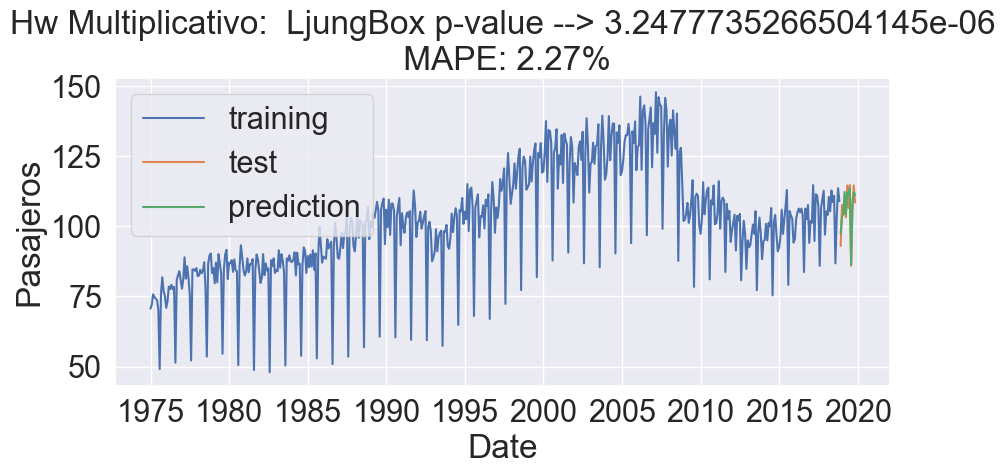

3.2477735266504145e-06


In [120]:
#Ajustamos Holt-Winters multiplicativo
hw_mul = ets.ExponentialSmoothing(
    ipi_tr['IPI Nacional'],
    trend='add',
    damped_trend=False,
    seasonal='mul',
    seasonal_periods=12
).fit()

print(hw_mul.summary())
eval_model(hw_mul, ipi_tr['IPI Nacional'], ipi_tst['IPI Nacional'], 'Hw Multiplicativo')

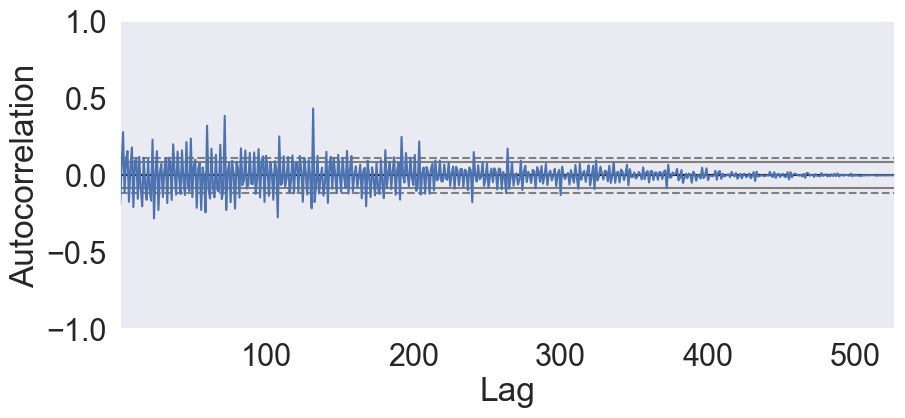

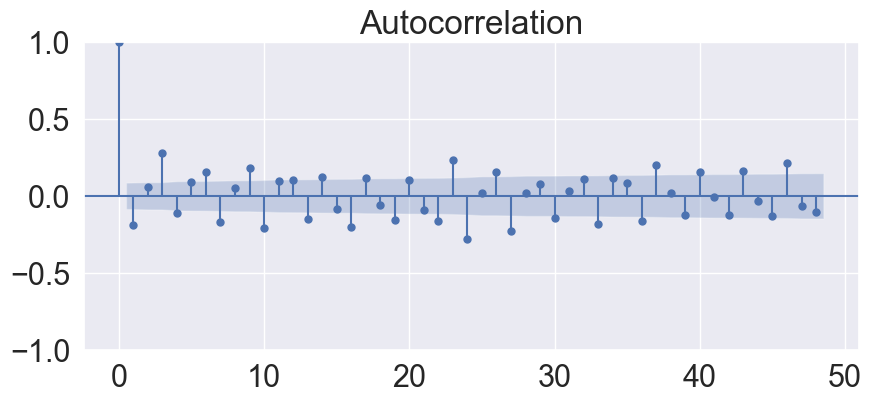

,lb_stat,lb_pvalue
1,19.283152,1.126964e-05
2,20.987894,2.770364e-05
3,62.783696,1.493882e-13
4,69.605009,2.750286e-14
5,74.016262,1.492324e-14
6,87.245760,1.130127e-16
7,103.194381,2.359127e-19
8,104.707262,4.644198e-19
9,122.273091,4.574104e-22
10,145.420905,3.255703e-26


In [121]:
#Evaluación del modelo de suavizado

plt.clf()
autocorrelation_plot(hw_mul.resid)
plt.show()

plot_acf(hw_mul.resid, lags=48)
plt.show()

sm.stats.acorr_ljungbox(hw_mul.resid, lags=12, return_df=True)

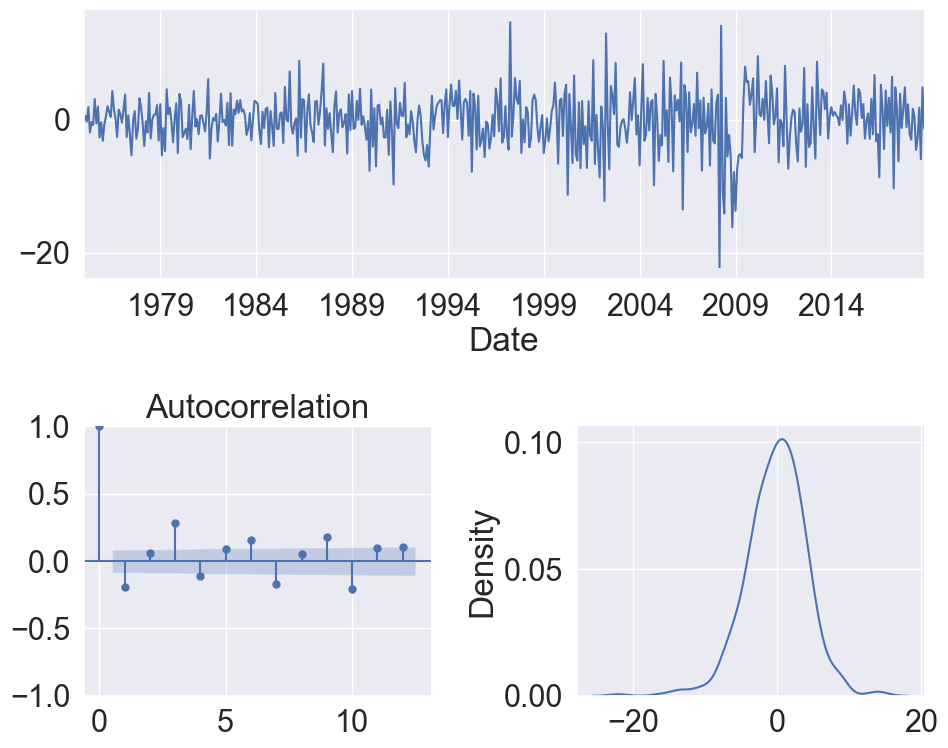

** Mean of the residuals:  -0.09

** Ljung Box Test, p-value: 0.0 (<0.05, Correlated)

** Jarque Bera Normality Test, p_value: 0.0 (<0.05, Not-normal)

** AD Fuller, p_value: 0.0 (<0.05, Stationary)


(<Axes: xlabel='Date'>,
 <Axes: title={'center': 'Autocorrelation'}>,
 <Axes: ylabel='Density'>)

In [122]:
residcheck(pd.Series(hw_mul.resid), 12)



El modelo de suavizado elegido es un Holt-Winters, ya que la serie del IPI Nacional muestra claramente una tendencia y un patrón que se repite cada año, y este tipo de modelo es el adecuado para series que tienen ambas características.
Una condición importante en los modelos de series temporales es que, una vez ajustado el modelo, en los residuos no quede ningún patrón claro. Es decir, los errores deberían comportarse de forma aleatoria y no mostrar relación entre sí.
Para comprobarlo se utiliza el test de Ljung-Box. En este caso, los valores obtenidos son muy pequeños (menores que 0.05), lo que indica que los residuos todavía presentan cierta relación entre ellos. Esto significa que el modelo de suavizado captura parte del comportamiento de la serie, pero no explica completamente toda su dinámica.


In [123]:
!pip install pmdarima

In [124]:
#Modelo de autoarima

import pmdarima as pm

#Partición training-test
ipi_tr = ipi.iloc[:-12]
ipi_tst = ipi.iloc[-12:]

arima_auto = pm.auto_arima(ipi_tr['IPI Nacional'], start_p=1, start_q=1, test='adf', max_p=5, max_q=5, m=12, d=None, seasonal=True, D=None, trace=True, error_action='ignore', suppress_warnings=True, stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=3046.634, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4458.565, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3681.071, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4456.575, Time=0.01 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=3682.487, Time=0.17 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=3151.513, Time=0.19 sec
 ARIMA(1,1,1)(2,0,1)[12] intercept   : AIC=3030.648, Time=0.83 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : AIC=3127.033, Time=0.49 sec
 ARIMA(1,1,1)(2,0,2)[12] intercept   : AIC=3009.076, Time=1.04 sec
 ARIMA(1,1,1)(1,0,2)[12] intercept   : AIC=3017.301, Time=1.37 sec
 ARIMA(0,1,1)(2,0,2)[12] intercept   : AIC=3038.957, Time=1.30 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=3110.025, Time=0.81 sec
 ARIMA(2,1,1)(2,0,2)[12] intercept   : AIC=2986.075, Time=1.23 sec
 ARIMA(2,1,1)(1,0,2)[12]

In [125]:
print(arima_auto.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                       y   No. Observations:                  527
Model:             SARIMAX(2, 1, 1)x(2, 0, [1, 2], 12)   Log Likelihood               -1484.042
Date:                                 Sun, 03 May 2026   AIC                           2984.084
Time:                                         17:54:08   BIC                           3018.206
Sample:                                     01-01-1975   HQIC                          2997.444
                                          - 11-01-2018                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6563      0.085     -7.699      0.000      -0.823      -0

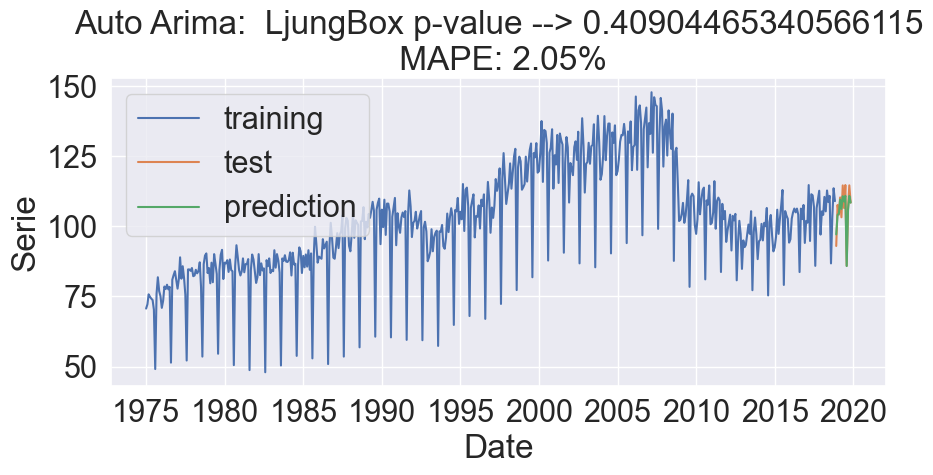

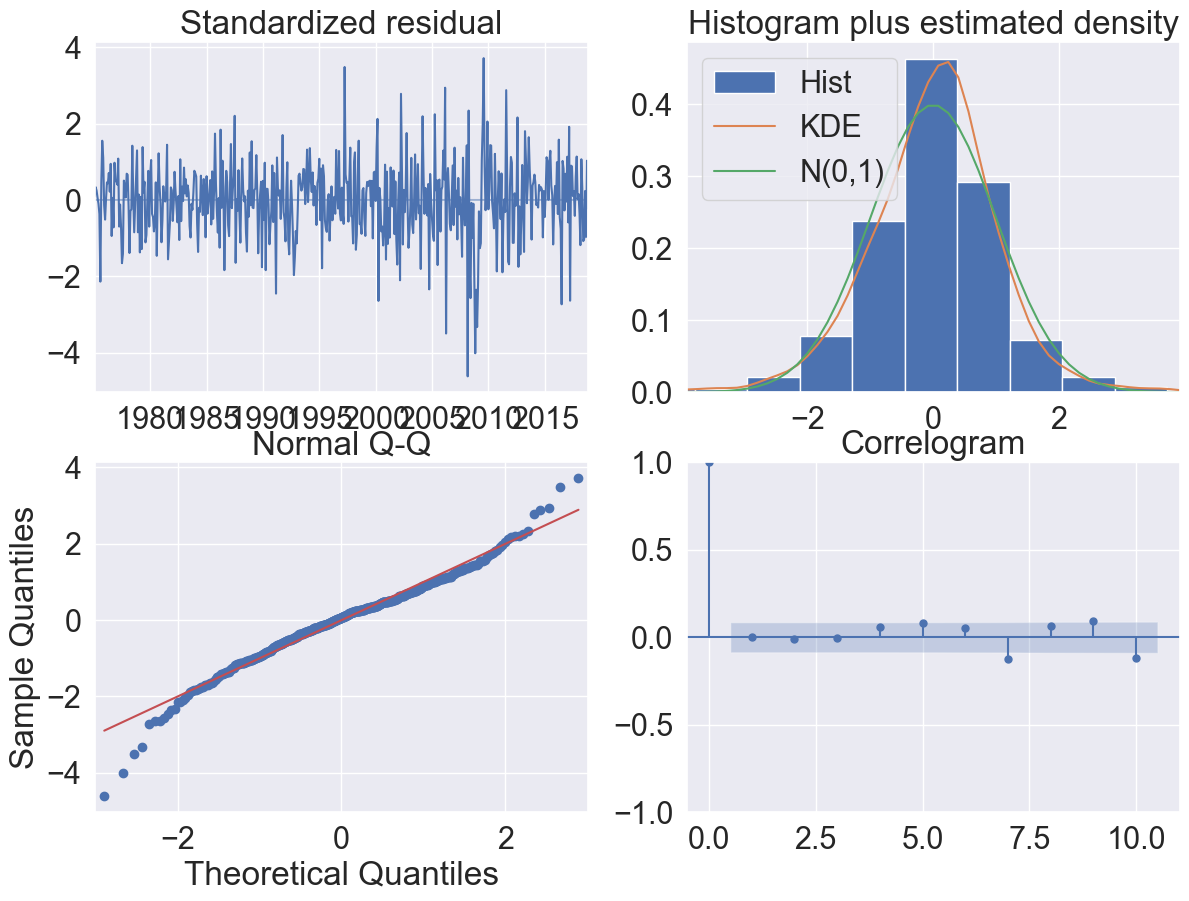

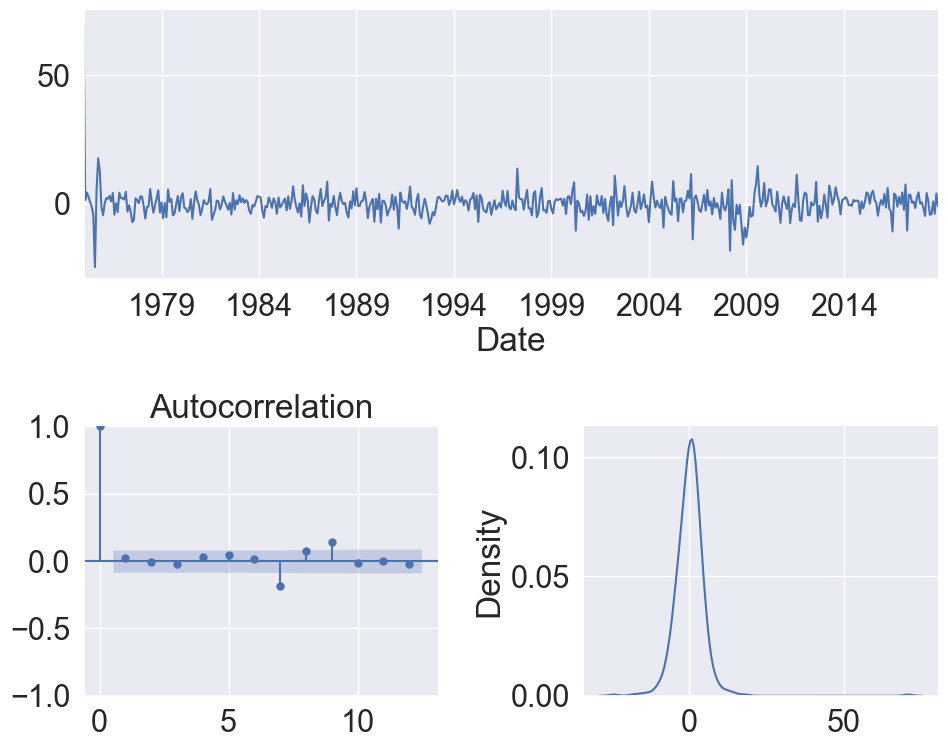

** Mean of the residuals:  0.13

** Ljung Box Test, p-value: 0.409 (>0.05, Uncorrelated)

** Jarque Bera Normality Test, p_value: 0.0 (<0.05, Not-normal)

** AD Fuller, p_value: 0.0 (<0.05, Stationary)


(<Axes: xlabel='Date'>,
 <Axes: title={'center': 'Autocorrelation'}>,
 <Axes: ylabel='Density'>)

In [126]:
#Evaluación del modelo de autoarima
eval_model_Aarima(arima_auto, ipi_tr['IPI Nacional'], ipi_tst['IPI Nacional'], 'Auto Arima')

sm.stats.acorr_ljungbox(arima_auto.resid(), lags=12, return_df=True)

residcheck(arima_auto.resid(),12)

**Respuestas**:

- El modelo elegido por autoarima es un SARIMAX(2,1,1)(2,0,2)[12], que tiene en cuenta tanto la dependencia entre los datos como la estacionalidad anual. En general, el modelo se ajusta bastante bien a la serie y permite obtener predicciones razonables.
La mayoría de los parámetros del modelo son significativos, ya que sus p-values son menores que 0.05. Solo uno de los parámetros estacionales no resulta significativo.
En comparación con el modelo de suavizado anterior, el modelo autoarima mejora la capacidad predictiva, ya que captura mejor la estructura temporal de la serie.
El test de Ljung-Box se utiliza para comprobar si los residuos del modelo están relacionados entre sí. La hipótesis nula (H0) indica que no hay autocorrelación en los residuos. En este caso, el p-value es mayor que 0.05, por lo que no se rechaza H0.
- Una condición muy importante es que los residuos no tengan relación entre ellos, es decir, que se comporten de forma aleatoria.
En este caso sí se cumple, ya que el test de Ljung-Box indica que no hay autocorrelación en los residuos. Esto significa que el modelo ha captado bien la información principal de la serie.

Técnicas no supervisadas


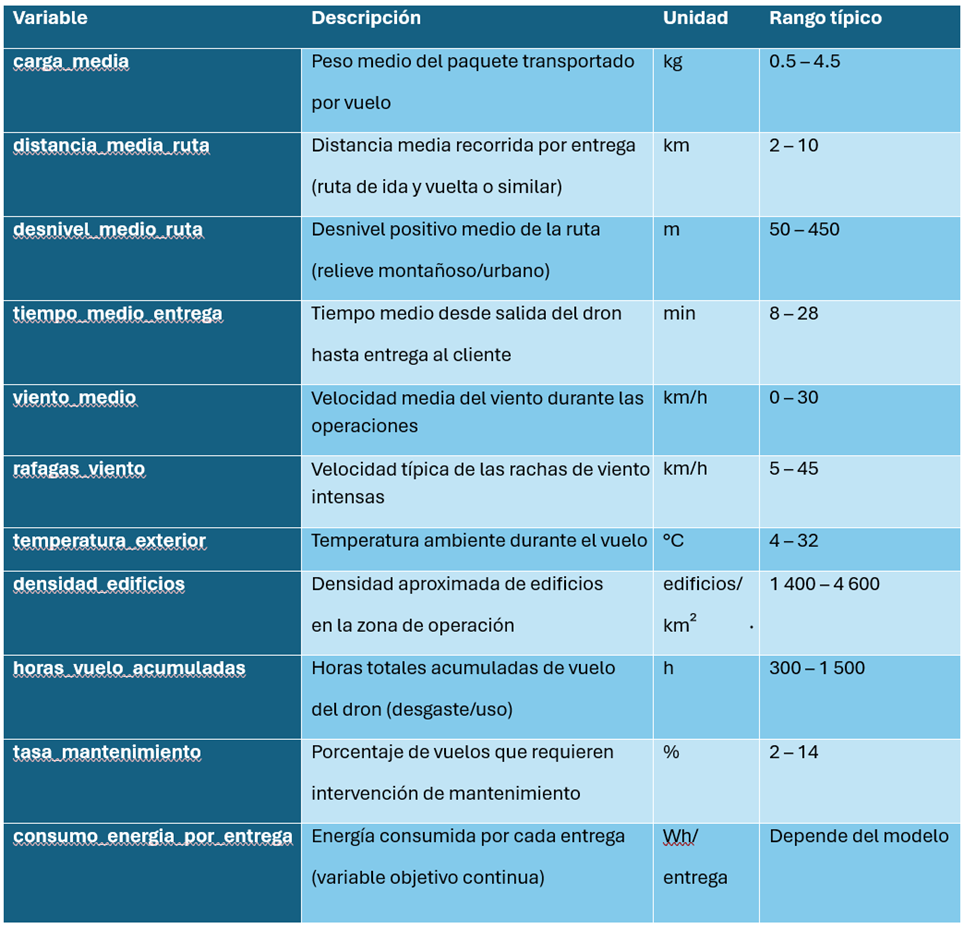

In [127]:
# Mostrar tabla de variables
from IPython.display import Image, display
display(Image(filename="../data/raw/Tabla_drones.png", width=600))

In [128]:
drones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   400 non-null    int64  
 1   carga_media                  400 non-null    float64
 2   distancia_media_ruta         400 non-null    float64
 3   desnivel_medio_ruta          400 non-null    float64
 4   tiempo_medio_entrega         400 non-null    float64
 5   viento_medio                 400 non-null    float64
 6   rafagas_viento               400 non-null    float64
 7   temperatura_exterior         400 non-null    float64
 8   densidad_edificios           400 non-null    float64
 9   horas_vuelo_acumuladas       400 non-null    float64
 10  tasa_mantenimiento           400 non-null    float64
 11  consumo_energia_por_entrega  400 non-null    float64
dtypes: float64(11), int64(1)
memory usage: 37.6 KB


In [129]:
drones.head()

,Unnamed: 0,carga_media,distancia_media_ruta,desnivel_medio_ruta,tiempo_medio_entrega,viento_medio,rafagas_viento,temperatura_exterior,densidad_edificios,horas_vuelo_acumuladas,tasa_mantenimiento,consumo_energia_por_entrega
0,0,3.516321,4.012980,364.339877,13.204373,9.705709,31.813419,17.088730,1567.771831,927.729288,1.765021,79.928719
1,1,1.291121,3.243403,324.781439,23.058810,2.433859,42.195099,11.255649,3950.373410,935.288648,8.961053,61.173511
2,2,0.701340,4.445645,320.917020,25.192340,12.357138,28.441942,2.757923,3594.852928,678.476208,6.398269,67.613639
3,3,1.768346,7.551582,192.266707,23.525792,14.953837,25.177178,20.490093,3872.323027,846.657310,8.684453,74.351774
4,4,3.721639,5.684206,242.498209,15.133995,13.975283,27.088913,24.486237,1811.492315,162.696500,13.019751,75.758522


In [130]:
drones.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,400.0,199.500000,115.614301,0.000000,99.750000,199.500000,299.250000,399.000000
carga_media,400.0,2.500000,1.001252,-0.228432,1.720361,2.537182,3.226867,5.155563
distancia_media_ruta,400.0,6.000000,2.002505,2.166444,4.521445,5.625818,7.553334,10.990625
desnivel_medio_ruta,400.0,250.000000,100.125235,-28.907458,181.305191,266.479508,321.981181,484.245012
tiempo_medio_entrega,400.0,18.000000,5.006262,4.260663,13.938737,18.781325,21.481049,29.511164
viento_medio,400.0,15.000000,7.008766,0.313970,9.735401,14.270891,19.672838,34.792081
rafagas_viento,400.0,25.000000,10.012523,-2.787511,18.389341,26.058017,32.432280,46.093555
temperatura_exterior,400.0,18.000000,7.008766,-0.534723,12.978330,17.892574,22.445579,39.461143
densidad_edificios,400.0,3000.000000,801.001879,533.113244,2445.730107,2986.119031,3521.523752,5660.195427
horas_vuelo_acumuladas,400.0,900.000000,300.375705,-19.672011,714.358914,894.006270,1102.743143,1868.423740


In [131]:
#Copia de trabajo
dr = drones.copy()

#Eliminar Unnamed:0
dr = dr.drop(columns=['Unnamed: 0'])

dr.head()

,carga_media,distancia_media_ruta,desnivel_medio_ruta,tiempo_medio_entrega,viento_medio,rafagas_viento,temperatura_exterior,densidad_edificios,horas_vuelo_acumuladas,tasa_mantenimiento,consumo_energia_por_entrega
0,3.516321,4.012980,364.339877,13.204373,9.705709,31.813419,17.088730,1567.771831,927.729288,1.765021,79.928719
1,1.291121,3.243403,324.781439,23.058810,2.433859,42.195099,11.255649,3950.373410,935.288648,8.961053,61.173511
2,0.701340,4.445645,320.917020,25.192340,12.357138,28.441942,2.757923,3594.852928,678.476208,6.398269,67.613639
3,1.768346,7.551582,192.266707,23.525792,14.953837,25.177178,20.490093,3872.323027,846.657310,8.684453,74.351774
4,3.721639,5.684206,242.498209,15.133995,13.975283,27.088913,24.486237,1811.492315,162.696500,13.019751,75.758522


In [132]:
#Matriz de correlaciones
corr = dr.corr()
corr.round(2)


,carga_media,distancia_media_ruta,desnivel_medio_ruta,tiempo_medio_entrega,viento_medio,rafagas_viento,temperatura_exterior,densidad_edificios,horas_vuelo_acumuladas,tasa_mantenimiento,consumo_energia_por_entrega
carga_media,1.00,-0.11,0.10,-0.91,-0.01,0.01,-0.12,-0.67,-0.07,0.37,0.87
distancia_media_ruta,-0.11,1.00,-0.93,0.34,0.90,-0.90,0.66,0.10,-0.04,0.09,0.08
desnivel_medio_ruta,0.10,-0.93,1.00,-0.31,-0.84,0.84,-0.62,-0.09,0.03,-0.10,-0.04
tiempo_medio_entrega,-0.91,0.34,-0.31,1.00,0.25,-0.25,0.29,0.63,0.05,-0.30,-0.76
viento_medio,-0.01,0.90,-0.84,0.25,1.00,-1.00,0.63,0.03,-0.03,0.10,0.13
rafagas_viento,0.01,-0.90,0.84,-0.25,-1.00,1.00,-0.63,-0.03,0.03,-0.10,-0.13
temperatura_exterior,-0.12,0.66,-0.62,0.29,0.63,-0.63,1.00,0.10,0.00,0.04,-0.17
densidad_edificios,-0.67,0.10,-0.09,0.63,0.03,-0.03,0.10,1.00,0.05,-0.21,-0.59
horas_vuelo_acumuladas,-0.07,-0.04,0.03,0.05,-0.03,0.03,0.00,0.05,1.00,-0.02,-0.06
tasa_mantenimiento,0.37,0.09,-0.10,-0.30,0.10,-0.10,0.04,-0.21,-0.02,1.00,0.34


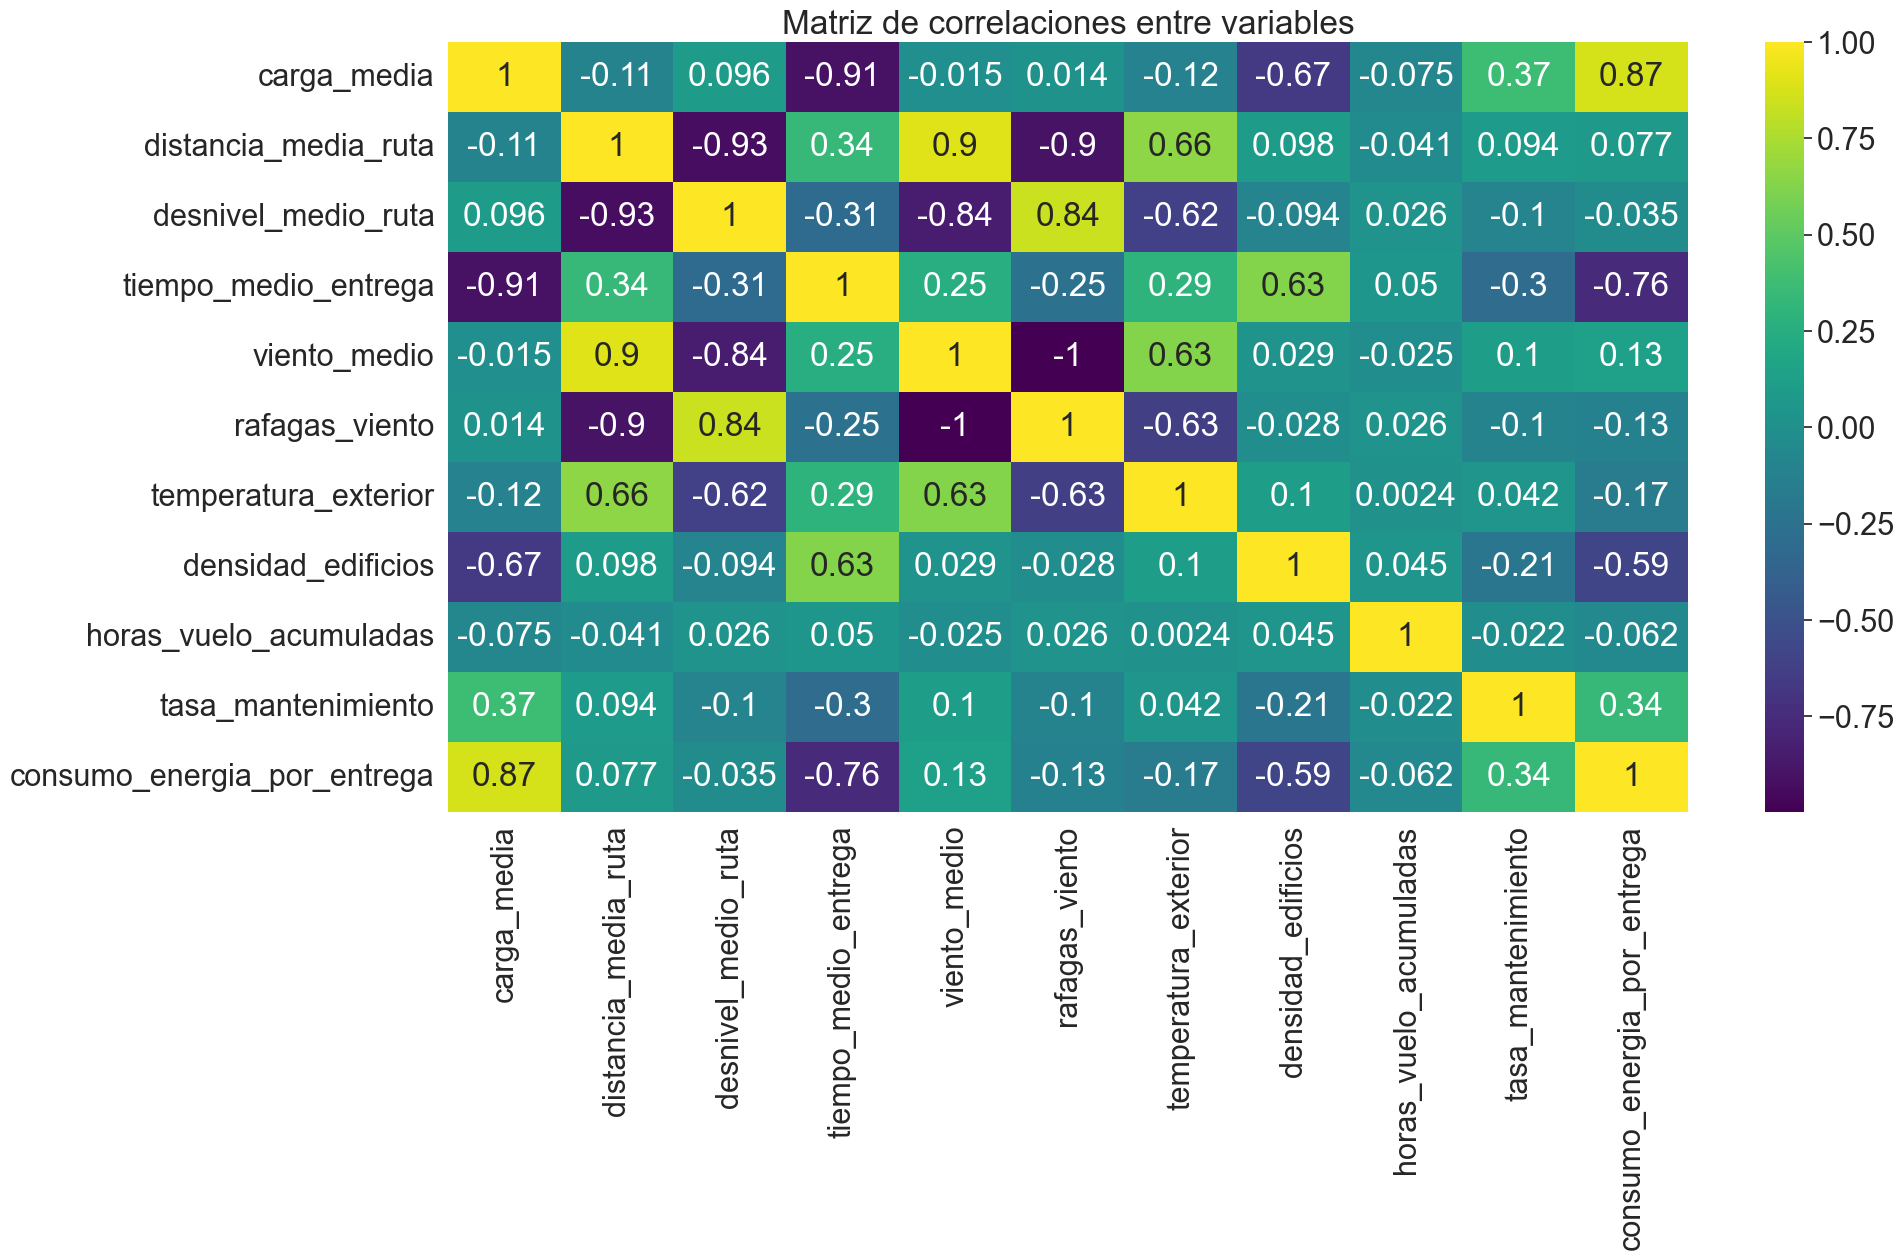

In [133]:
#Representamos graficamente
plt.figure(figsize=(20,10))

sns.heatmap(corr, annot=True, cmap='viridis', center=0)

plt.title('Matriz de correlaciones entre variables')
plt.show()

Vemos en la matriz de correlaciones relaciones fuertes entre algunas variables, por ejemplo, viento_medio y rafagas_viento (-1.00), distancia_media_ruta y desnivel_medio_ruta (-0.93), y carga_media y tiempo_medio_entrega (-0.91).



- Si usaramos un modelo de regresión para estimar consumo_energia_por_entrega, podría aparecer un problema de multicolinealidad, es decir, alta correlación entre predictores, que puede provocar coeficientes inestables, errores estándar altos y dificultad para interpretar el efecto individual de cada variable.

- Podríamos aplicar un análisis de componentes principales (PCA), que transforma las variables correlacionadas en componentes no correlacionadas para reducir la dimensionalidad del conjunto de datos.

In [134]:
#Eliminamos identificador y variable objetivo
X = drones.drop(columns=['Unnamed: 0','consumo_energia_por_entrega'])

X.head()

,carga_media,distancia_media_ruta,desnivel_medio_ruta,tiempo_medio_entrega,viento_medio,rafagas_viento,temperatura_exterior,densidad_edificios,horas_vuelo_acumuladas,tasa_mantenimiento
0,3.516321,4.012980,364.339877,13.204373,9.705709,31.813419,17.088730,1567.771831,927.729288,1.765021
1,1.291121,3.243403,324.781439,23.058810,2.433859,42.195099,11.255649,3950.373410,935.288648,8.961053
2,0.701340,4.445645,320.917020,25.192340,12.357138,28.441942,2.757923,3594.852928,678.476208,6.398269
3,1.768346,7.551582,192.266707,23.525792,14.953837,25.177178,20.490093,3872.323027,846.657310,8.684453
4,3.721639,5.684206,242.498209,15.133995,13.975283,27.088913,24.486237,1811.492315,162.696500,13.019751


In [135]:
!pip install factor_analyzer

In [136]:
#Bartlett
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

chi2, p = calculate_bartlett_sphericity(X)

print("Bartlett chi2:", chi2)
print("p-value:", p)

Bartlett chi2: 5493.755967537954
p-value: 0.0


In [137]:
#KMO
kmo_vars, kmo_global = calculate_kmo(X)

print("KMO global:", kmo_global)

pd.DataFrame({'Variable': X.columns,'KMO': kmo_vars})

KMO global: 0.7862846343194966


,Variable,KMO
0,carga_media,0.625426
1,distancia_media_ruta,0.842861
2,desnivel_medio_ruta,0.844200
3,tiempo_medio_entrega,0.682467
4,viento_medio,0.749446
5,rafagas_viento,0.750110
6,temperatura_exterior,0.982189
7,densidad_edificios,0.934711
8,horas_vuelo_acumuladas,0.584111
9,tasa_mantenimiento,0.914018


In [138]:
from sklearn.preprocessing import StandardScaler

#Creamos el objeto de escalado
scaler = StandardScaler()

#Estandarizamos las variables para que todas tengan la misma escala
X_scaled = scaler.fit_transform(X)

In [139]:
from sklearn.decomposition import PCA

#Ajustamos un PCA inicial con todas las componentes
pca = PCA()

#Obtenemos los scores del PCA
scores = pca.fit_transform(X_scaled)

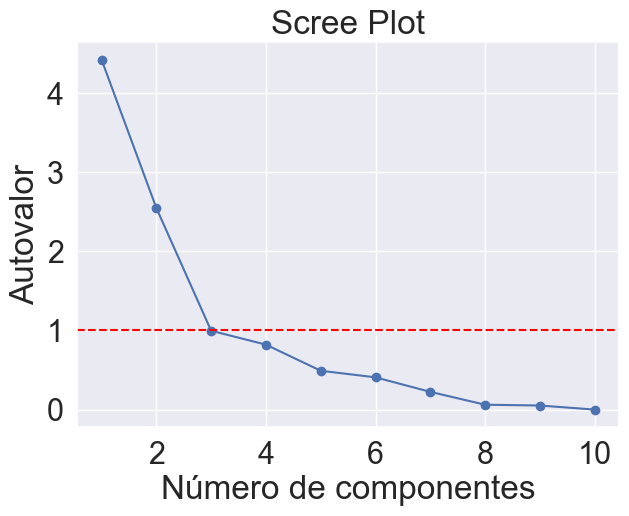

In [140]:
#Representamos los autovalores para decidir el número de componentes
plt.figure(figsize=(7,5))

plt.plot(range(1, len(pca.explained_variance_) + 1), pca.explained_variance_, marker='o')

#Añadimos la línea horizontal del criterio de Kaiser (autovalor = 1)
plt.axhline(y=1, color='red', linestyle='--')

plt.xlabel("Número de componentes")
plt.ylabel("Autovalor")
plt.title("Scree Plot")
plt.show()

In [141]:
#Creamos una tabla con la varianza explicada y acumulada
var_exp = pd.DataFrame({'Componente': range(1, len(pca.explained_variance_ratio_) + 1), 'Varianza explicada': pca.explained_variance_ratio_, 'Varianza acumulada': pca.explained_variance_ratio_.cumsum()})

var_exp

,Componente,Varianza explicada,Varianza acumulada
0,1,0.440990,0.440990
1,2,0.254099,0.695088
2,3,0.099414,0.794502
3,4,0.081905,0.876408
4,5,0.048992,0.925400
5,6,0.040707,0.966107
6,7,0.022409,0.988516
7,8,0.006217,0.994733
8,9,0.005198,0.999931
9,10,0.000069,1.000000


In [142]:
#Seleccionamos el número de componentes usando el criterio de Kaiser
n_comp = sum(pca.explained_variance_ > 1)

#Mostramos el número de componentes retenidas
print("Número de componentes seleccionadas:", n_comp)

Número de componentes seleccionadas: 2


In [143]:
#Ajustamos el PCA final con el número de componentes seleccionado
pca_final = PCA(n_components=n_comp)

#Calculamos los scores finales
scores_final = pca_final.fit_transform(X_scaled)

#Calculamos las cargas de las variables en las componentes
loadings = pd.DataFrame(pca_final.components_.T, columns=[f'PC{i+1}' for i in range(n_comp)], index=X.columns)

#Mostramos
loadings

,PC1,PC2
carga_media,-0.124838,0.571973
distancia_media_ruta,0.453712,0.095493
desnivel_medio_ruta,-0.436250,-0.098159
tiempo_medio_entrega,0.232899,-0.505034
viento_medio,0.443140,0.151994
rafagas_viento,-0.442687,-0.152569
temperatura_exterior,0.359665,0.041821
densidad_edificios,0.109555,-0.482272
horas_vuelo_acumuladas,-0.007551,-0.072300
tasa_mantenimiento,0.015553,0.336290


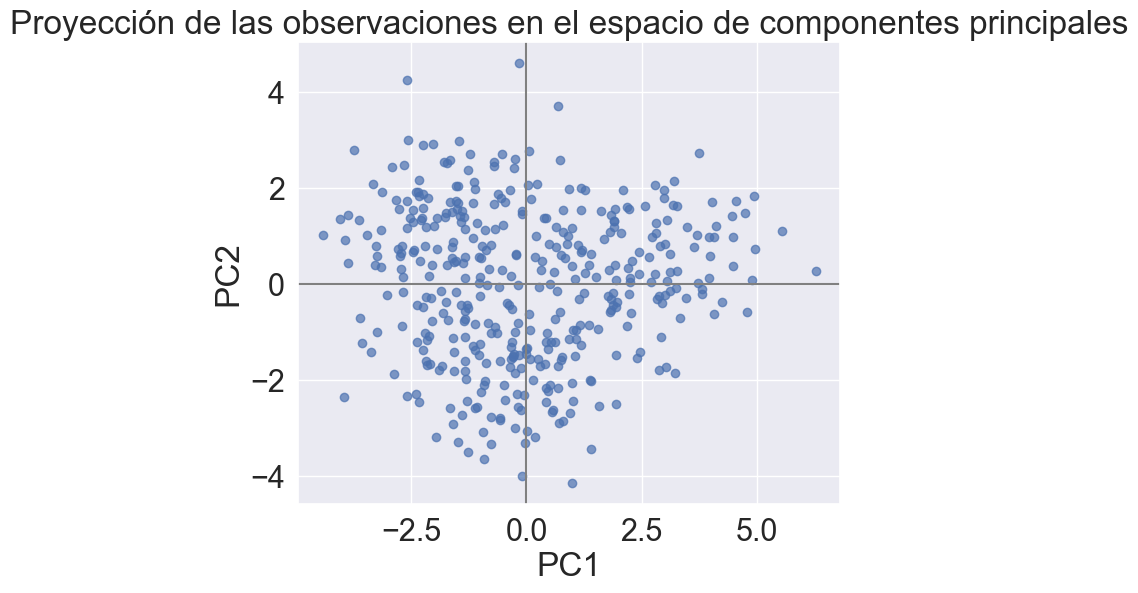

In [144]:
#Gráfico de las dos primeras componentes principales

plt.figure(figsize=(7,6))

#Representamos las observaciones
plt.scatter(scores_final[:,0], scores_final[:,1], alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Proyección de las observaciones en el espacio de componentes principales")

plt.axhline(0, color='grey')
plt.axvline(0, color='grey')

plt.show()

In [145]:
#Definimos biplot
def biplot(score,coeff,labels=None):
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    plt.scatter(xs * scalex,ys * scaley) #, c = cities.index.tolist())
    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1],color = 'r',alpha = 0.5)
        if labels is None:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, "Var"+str(i+1), color = 'g', ha = 'center', va = 'center')
        else:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color = 'g', ha = 'center', va = 'center')
    plt.xlim(-1,1)
    plt.ylim(-1,1)
    plt.xlabel("PC{}".format(1))
    plt.ylabel("PC{}".format(2))
    plt.grid()


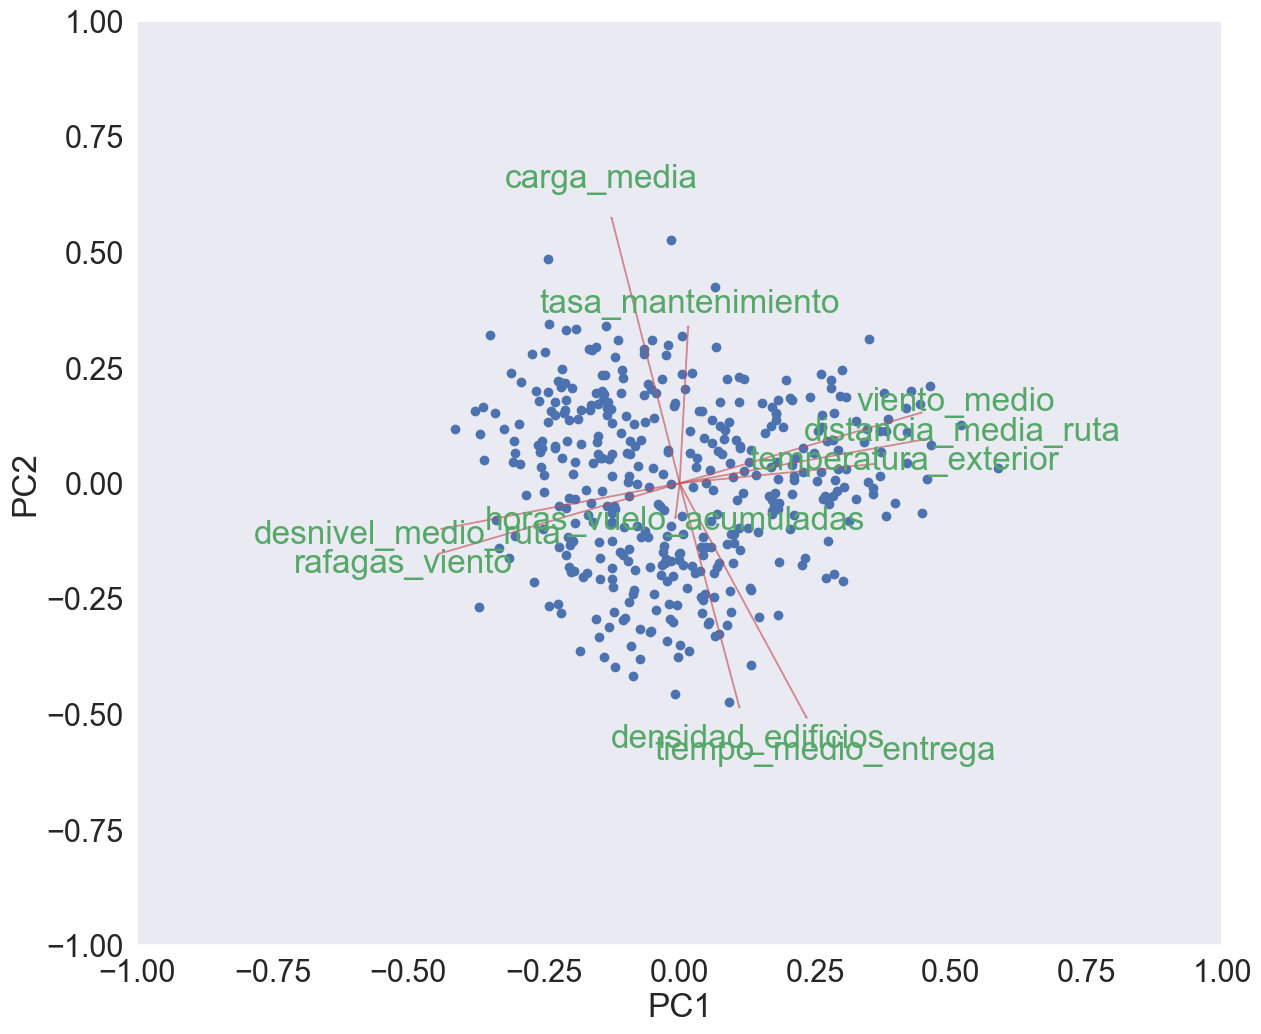

In [146]:
#Biplot del PCA con las dos primeras componentes
plt.figure(figsize=(14,12))

biplot(scores_final[:,0:2],
       np.transpose(pca_final.components_[0:2,:]),
       X.columns)

plt.show()



- El índice KMO global que obtenemos es 0.786, así que podríamos aplicar una técnica de reducción de dimensionalidad. Además, los valores de KMO por variable son en general aceptables, ya que todos superan 0.5.

- Sí, es adecuado reducir la dimensionalidad del conjunto de predictores, porque existe suficiente estructura de correlación entre las variables, tal y como veíamos también en la matriz de correlaciones del apartado anterior.

- Se retienen 2 componentes principales, ya que son las únicas con autovalor mayor que 1, que explican aproximadamente el 69.5% de la variabilidad total.

- La primera componente (PC1) está relacionada principalmente con variables relacionadas con las características de la ruta y las condiciones meteorológicas, como distancia_media_ruta, viento_medio, temperatura_exterior, y en sentido contrario desnivel_medio_ruta y rafagas_viento.

- La segunda componente (PC2) recoge sobre todo información relacionada con las condiciones operativas del dron, como carga_media y tasa_mantenimiento, frente a variables como tiempo_medio_entrega y densidad_edificios en sentido opuesto.

- El gráfico de las dos primeras componentes y el biplot podemos ver la proyección de las observaciones en el espacio reducido y la contribución de las variables originales a cada componente.

In [147]:
#Rescatamos los scores del PCA para las componentes seleccionadas
scores_pca = pd.DataFrame(
    scores_final,
    columns=[f'PC{i+1}' for i in range(n_comp)])

#Comprobamos
scores_pca.head()

,PC1,PC2
0,-2.212589,0.792038
1,-2.334032,-2.456632
2,-1.126526,-2.584812
3,1.194103,-1.270996
4,-0.267171,2.422014


In [148]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist

#Creamos función scree_plot_kmeans para buscar el número de clusters óptimo con WSS, silueta y % de varianza explicada
def scree_plot_kmeans(data, n_max):

    range_n_clusters = range(2, n_max)
    inertias = []
    silhouette = []
    var_perc = []

    for n_clusters in range_n_clusters:

        # Ajustamos el modelo KMeans
        modelo_kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=123)

        modelo_kmeans.fit(data)
        cluster_labels = modelo_kmeans.fit_predict(data)

        #Guardamos varianza intra
        inertias.append(modelo_kmeans.inertia_)

        #Guardamos silueta media
        silhouette.append(silhouette_score(data, cluster_labels))

        #Calculamos el % de variabilidad explicada
        tss = sum(pdist(data)**2) / data.shape[0]
        bss = tss - modelo_kmeans.inertia_
        var_perc.append(bss / tss * 100)

    #Representamos los tres criterios
    fig, ax = plt.subplots(1, 3, figsize=(16, 5))

    ax[0].plot(range_n_clusters, inertias, marker='o')
    ax[0].set_title("Scree plot varianza intra")
    ax[0].set_xlabel("Número de clusters")
    ax[0].set_ylabel("Inercia")

    ax[1].plot(range_n_clusters, silhouette, marker='o')
    ax[1].set_title("Scree plot silueta")
    ax[1].set_xlabel("Número de clusters")
    ax[1].set_ylabel("Silueta media")

    ax[2].plot(range_n_clusters, var_perc, marker='o')
    ax[2].set_title("Scree plot % varianza")
    ax[2].set_xlabel("Número de clusters")
    ax[2].set_ylabel("% variabilidad explicada")

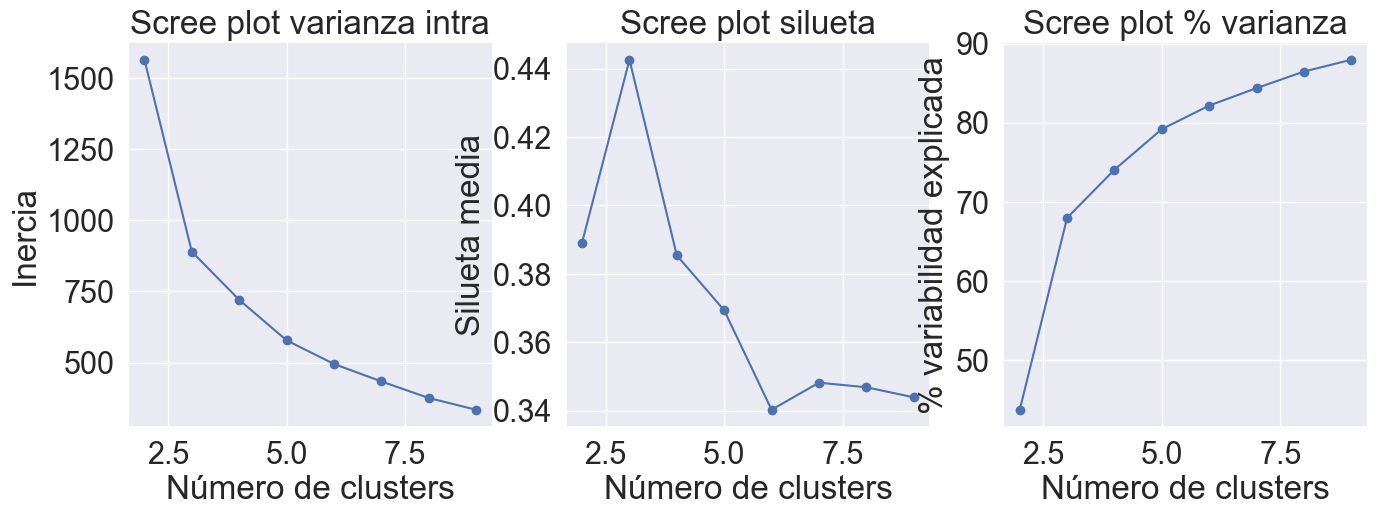

In [149]:
#Exploramos el número de clusters óptimo sobre los scores del PCA
scree_plot_kmeans(scores_pca, 10)
plt.show()

In [150]:
#Modelo KMeans con el número de clusters elegido
modelo_kmeans = KMeans(n_clusters=3, n_init=25, random_state=123)

#Ajustamos el modelo sobre los scores del PCA
modelo_kmeans.fit(scores_pca)

#Varianza intra del modelo
print("Varianza intra:", modelo_kmeans.inertia_)

#Centroides del modelo
print("Centroides:")
print(modelo_kmeans.cluster_centers_)

#Etiquetas de cluster asignadas
cluster_labels = modelo_kmeans.labels_
print("Primeras etiquetas:")
print(cluster_labels[:10])

Varianza intra: 889.7405189359769
Centroides:
[[-1.74015059  1.28222576]
 [ 2.45992412  0.49999734]
 [-0.55291885 -1.73636763]]
Primeras etiquetas:
[0 2 2 2 0 1 2 0 0 1]


In [151]:
#Calculamos la silueta media del clustering
from sklearn.metrics import silhouette_score

sil_media = silhouette_score(scores_pca, cluster_labels)
print("Silueta media:", sil_media)

Silueta media: 0.4426188099712311


In [152]:
#Calculamos el % de variabilidad explicada
from scipy.spatial.distance import pdist

tss = sum(pdist(scores_pca)**2) / scores_pca.shape[0]
bss = tss - modelo_kmeans.inertia_
var_exp_cluster = bss / tss * 100

print("% variabilidad explicada:", var_exp_cluster)

% variabilidad explicada: 67.99901590201371


In [153]:
#Presentamos los centroides en dataframe
centroides = pd.DataFrame(modelo_kmeans.cluster_centers_, columns=scores_pca.columns)

centroides

,PC1,PC2
0,-1.740151,1.282226
1,2.459924,0.499997
2,-0.552919,-1.736368


In [154]:
#Añadimos el cluster a los scores del PCA
scores_pca['cluster_kmeans'] = cluster_labels

#Comprobamos
scores_pca.head()

,PC1,PC2,cluster_kmeans
0,-2.212589,0.792038,0
1,-2.334032,-2.456632,2
2,-1.126526,-2.584812,2
3,1.194103,-1.270996,2
4,-0.267171,2.422014,0


In [155]:
#Representación de los clusters en el plano PC1-PC2
import plotly.express as px

fig = px.scatter(scores_pca, x='PC1', y='PC2', color='cluster_kmeans', height=500, title='Clusters KMeans sobre el plano PC1-PC2')

fig.show()



- La solución con 3 grupos funciona bastante bien. La silueta de 0,44 indica que los grupos están bastante bien separados. Además, explican un 68% de los datos, así que representan bien la información.

- Los centroides de los clusters en el espacio de componentes principales son:
Cluster 0: PC1 = -1.74, PC2 = 1.28  
Cluster 1: PC1 = 2.46, PC2 = 0.50  
Cluster 2: PC1 = -0.55, PC2 = -1.74  

- En el biplot en el plano PC1-PC2 vemos la separación entre los tres grupos en el espacio reducido.

- En cuanto a la caracterización de los grupos, tenemos que tener en cuenta que PC1 resume principalmente variables relacionadas con la ruta y las condiciones meteorológicas y que PC2 recoge sobre todo condiciones operativas del dron. Así que, los clusters serían:
- Cluster 1 (PC1 alto): rutas más largas y condiciones meteorológicas más intensas.
- Cluster 0 (PC1 bajo y PC2 alto): mayor desnivel de ruta y mayor carga o mantenimiento del dron.
- Cluster 2 (PC2 bajo): mayor tiempo de entrega y mayor densidad de edificios.